## Incrementality studies show higher incremental contribution vs other channels
### Spend pulse test conducted
### 21st May - Meta Web spend upweighted 2x
### 4th June - Meta Web spend downweighted to 0%
### 18th June - Meta Web spend restored to normal levels
### Expectation from Phase 1 - Facebook channel - +420k NTS impact over 2 weeks
### Expectation from Phase 2 - Facebook channel - -840k NTS impact over 2 weeks
### Movement in UK baseline (non-attributed sales)
### iROAS for Meta, marginal iROAS estimate, IGM estimate, NC%

## Config

In [19]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from trino.dbapi import connect
from trino.auth import BasicAuthentication, OAuth2Authentication

TRINO_HOST = "turing-embedded-data-science-fte-mode.trino.galaxy.starburst.io"
TRINO_CATALOG = "trainline_data"


private_path = Path("private.json")

if private_path.exists():
    creds = json.loads(private_path.read_text())
    db_user = creds["email"]
    db_password = creds["password"]
    auth = BasicAuthentication(db_user, db_password)
else:
    db_user = os.getenv("db_user") or os.getenv("TRINO_USER")
    db_password = os.getenv("db_password") or os.getenv("TRINO_PASSWORD")

    if db_user and db_password:
        auth = BasicAuthentication(db_user, db_password)
    else:
        # Fall back to OAuth if no private.json / password creds are available
        db_user = db_user or os.getenv("EMAIL") or os.getenv("USER")
        auth = OAuth2Authentication()

conn = locals().get(
    "conn",
    connect(
        auth=auth,
        http_scheme="https",
        host=TRINO_HOST,
        port=443,
        user=db_user,
        catalog=TRINO_CATALOG,
    ),
)

In [60]:
# Global number formatting (disable scientific notation across notebook)
import matplotlib as mpl
import matplotlib.pyplot as plt

# Pandas tables: human-readable numeric formatting
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Numpy arrays/prints: suppress scientific notation
np.set_printoptions(suppress=True)

# Matplotlib axes: plain numbers, no 1e6-style offsets
mpl.rcParams["axes.formatter.useoffset"] = False
mpl.rcParams["axes.formatter.limits"] = (-99, 99)
mpl.rcParams["axes.unicode_minus"] = False

print("Notebook formatting set: scientific notation disabled for tables and plots.")

Notebook formatting set: scientific notation disabled for tables and plots.


## SQL Queries used

In [113]:
# Overall NTS
df_overall_nts = pd.read_sql("""
SELECT
    DATE(order_confirmed_date) AS activity_date,
    SUM(m_net_sales_amount_gbp) AS nts_gbp
FROM bi_dwh.fm_products fp
WHERE DATE(order_created_date) >= DATE('2025-01-01')
    -- standard fm_products filters
    AND record_type = 'SALES'
    AND order_id is not null
    AND order_confirmed_date is not null
    AND order_managed_group_id in ('20', '42')
    AND order_type_name not in ('change of journey', 'change over')
    -- business accounts
    AND LOWER(order_customer_id) NOT LIKE '%25kv%'
    AND order_region_name = 'United Kingdom'
GROUP BY 1
ORDER BY 1
""", conn)

#Channel Spend
df_channel_nts = pd.read_sql("""
SELECT
    DATE(activity_date) AS activity_date,
    SUM(marketing_spend_gbp) AS spend_gbp
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
    AND DATE(activity_date) >= DATE '2025-01-01'
    AND channel_0 = 'Web - Paid Social'
    AND channel_2 = 'Facebook'
    AND region = 'United Kingdom'
GROUP BY 1
ORDER BY 1
""", conn)

#Channel NTS and Orders
df_channel_nts_orders = pd.read_sql("""
WITH unknown_channel_nts AS (
    SELECT
        DATE(activity_date) AS activity_date,
        SUM(IF(channel_0 = 'Unknown', net_sales_gbp, 0)) AS unknown_nts,
        SUM(net_sales_gbp) AS total_nts,
        SUM(IF(channel_0 = 'Unknown', net_sales_gbp, 0)) / SUM(net_sales_gbp) AS proportion_nts_unknown
    FROM de_dwh_lf.marketing_orders mo
    WHERE region = 'United Kingdom'
        AND DATE(activity_date) >= DATE'2025-01-01'
    GROUP BY 1
),

marketing_channel_nts AS (
    SELECT
        DATE(activity_date) AS activity_date,
        channel_0,
        channel_1,
        channel_2,
        SUM(net_sales_gbp) AS nts_gbp
    FROM de_dwh_lf.marketing_orders mo
    WHERE region = 'United Kingdom'
        AND DATE(activity_date) >= DATE'2025-01-01'
        AND channel_0 != 'Unknown'
    GROUP BY 1,2,3,4
)

SELECT
    mcn.activity_date,
    mcn.channel_0,
    mcn.channel_1,
    mcn.channel_2,
    mcn.nts_gbp,
    mcn.nts_gbp / (1 - ucn.proportion_nts_unknown) AS scaled_nts_gbp
FROM marketing_channel_nts mcn
JOIN unknown_channel_nts ucn
    ON mcn.activity_date = ucn.activity_date
WHERE
    (mcn.channel_0 = 'Web - Paid Social' AND mcn.channel_2 = 'Facebook')
    OR (mcn.channel_0 = 'Web Direct' AND mcn.channel_2 = 'Web Direct')
ORDER BY 1,2
""", conn)

#New Customers by Channel
df_new_customers_channel = pd.read_sql("""
SELECT
    DATE(activity_date) AS activity_date,
    channel_0,
    channel_1,
    channel_2,
    SUM(new_customer_count) AS new_customers
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
    AND DATE(activity_date) >= DATE '2025-01-01'
    AND region = 'United Kingdom'
    AND channel_0 IN ('Web - Paid Social', 'Web Direct')
    AND channel_2 IN ('Facebook', 'Web Direct')
GROUP BY 1,2,3,4
ORDER BY 1,2,3,4
""", conn)

# Overall New Customers
df_overall_nc = pd.read_sql("""
SELECT
    DATE(activity_date) AS activity_date,
    SUM(new_customer_count) AS new_customers
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
    AND DATE(activity_date) >= DATE '2025-01-01'
    AND region = 'United Kingdom'
GROUP BY 1
ORDER BY 1
""", conn)

# Incremental Channel Data
df_incremental_channel = pd.read_sql("""
WITH inc_atts AS (
    SELECT
    t.*,
    CASE
            WHEN device = 'web' AND channel = 'Paid Search' THEN 'PPC'
            WHEN device = 'web' AND channel = 'Paid Social' THEN 'Web - Social'
            WHEN device = 'app' AND media_platform = 'Google App' THEN 'App - Low'
            WHEN device = 'app' AND channel = 'Paid Social' THEN 'App - Mid'
        ELSE 'other' End as channel_grouping
    FROM bi_dwh.incrementality_attribution t
),

inc_atts_daily_aggs AS (
    SELECT
        activity_date, region, channel_grouping,
        SUM(incremental_new_customer) AS iNC,
        SUM(incremental_gross_sales_eur) AS iNTS_eur,
        SUM(incremental_gross_sales_gbp) AS iNTS_gbp,
        SUM(spend_gbp) AS spend_gbp,
        SUM(spend_eur) AS spend_eur
    FROM inc_atts
    GROUP BY activity_date, region, channel_grouping
)

SELECT
    activity_date, region, channel_grouping,
    iNC, iNTS_eur, iNTS_gbp,
    iNTS_gbp / spend_gbp AS iROAS,
    spend_gbp / iNC AS iCPA_gbp,
    spend_eur / iNC AS iCPA_eur
FROM inc_atts_daily_aggs
WHERE iNC > 0 AND spend_gbp > 0
ORDER BY activity_date DESC
""", conn)

# Visits
df_visits = pd.read_sql("""
SELECT
    DATE(year_month_day) AS activity_date,
    COUNT(DISTINCT(visit_id)) AS visits
FROM bi_dwh.user_visits
WHERE platform IN ('mweb', 'dtweb')
    AND UPPER(region_name) = 'UNITED KINGDOM'
    AND DATE(year_month_day) >= DATE'2025-01-01'
GROUP BY 1
ORDER BY 1
""", conn)

print("✓ All queries executed successfully")
print(f"df_overall_nts: {df_overall_nts.shape}")
print(f"df_channel_nts: {df_channel_nts.shape}")
print(f"df_channel_nts_orders: {df_channel_nts_orders.shape}")
print(f"df_new_customers_channel: {df_new_customers_channel.shape}")
print(f"df_overall_nc: {df_overall_nc.shape}")
print(f"df_incremental_channel: {df_incremental_channel.shape}")
print(f"df_visits: {df_visits.shape}")

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_27293/1901271404.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_overall_nts = pd.read_sql("""
/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_27293/1901271404.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_channel_nts = pd.read_sql("""
/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_27293/1901271404.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_channel_nts_orders = pd.read_sql("""
/var/folders/xc/5db63q_n4mn023lqftp12

✓ All queries executed successfully
df_overall_nts: (538, 2)
df_channel_nts: (537, 2)
df_channel_nts_orders: (1075, 6)
df_new_customers_channel: (1075, 5)
df_overall_nc: (538, 2)
df_incremental_channel: (13260, 9)
df_visits: (538, 2)


In [114]:
# ===== ASSEMBLE df_analysis =====
# Start with channel NTS orders as base
df_analysis = df_channel_nts_orders.copy()
df_analysis.columns = ['activity_date', 'channel_0', 'channel_1', 'channel_2', 'nts_gbp', 'scaled_nts_gbp']

# Pivot to get Facebook and Direct as separate columns
df_fb = df_analysis[df_analysis['channel_0'] == 'Web - Paid Social'][['activity_date', 'scaled_nts_gbp']].copy()
df_fb.columns = ['activity_date', 'web_paid_social_scaled_nts_gbp']

df_dir = df_analysis[df_analysis['channel_0'] == 'Web Direct'][['activity_date', 'scaled_nts_gbp']].copy()
df_dir.columns = ['activity_date', 'web_direct_scaled_nts_gbp']

# Merge Facebook and Direct NTS
df_analysis_base = df_fb.merge(df_dir, on='activity_date', how='outer')

# Add Facebook spend
df_analysis_base = df_analysis_base.merge(df_channel_nts, on='activity_date', how='left')
df_analysis_base.rename(columns={'spend_gbp': 'facebook_paid_social_spend_gbp'}, inplace=True)

# Add new customers by channel
df_fb_nc = df_new_customers_channel[df_new_customers_channel['channel_0'] == 'Web - Paid Social'][['activity_date', 'new_customers']].copy()
df_fb_nc.columns = ['activity_date', 'web_paid_social_new_customers']

df_dir_nc = df_new_customers_channel[df_new_customers_channel['channel_0'] == 'Web Direct'][['activity_date', 'new_customers']].copy()
df_dir_nc.columns = ['activity_date', 'web_direct_new_customers']

df_analysis_base = df_analysis_base.merge(df_fb_nc, on='activity_date', how='left')
df_analysis_base = df_analysis_base.merge(df_dir_nc, on='activity_date', how='left')

# Add overall NTS and NC
df_analysis_base = df_analysis_base.merge(df_overall_nts, on='activity_date', how='left')
df_analysis_base.rename(columns={'nts_gbp': 'total_nts_gbp'}, inplace=True)

df_analysis_base = df_analysis_base.merge(df_overall_nc, on='activity_date', how='left')
df_analysis_base.rename(columns={'new_customers': 'total_new_customers'}, inplace=True)

# Add visits
df_analysis_base = df_analysis_base.merge(df_visits, on='activity_date', how='left')

# Sort by date
df_analysis_base = df_analysis_base.sort_values('activity_date').reset_index(drop=True)

# Rename to df_analysis
df_analysis = df_analysis_base.copy()

print("✓ df_analysis assembled successfully")
print(f"Shape: {df_analysis.shape}")
print(f"\nColumns: {list(df_analysis.columns)}")
print(f"\nFirst few rows:")
display(df_analysis.head())
print(f"\nData summary:")
display(df_analysis.describe())

✓ df_analysis assembled successfully
Shape: (538, 9)

Columns: ['activity_date', 'web_paid_social_scaled_nts_gbp', 'web_direct_scaled_nts_gbp', 'facebook_paid_social_spend_gbp', 'web_paid_social_new_customers', 'web_direct_new_customers', 'total_nts_gbp', 'total_new_customers', 'visits']

First few rows:


,activity_date,web_paid_social_scaled_nts_gbp,web_direct_scaled_nts_gbp,facebook_paid_social_spend_gbp,web_paid_social_new_customers,web_direct_new_customers,total_nts_gbp,total_new_customers,visits
0,2025-01-01,"254,062.31","106,741.61","4,030.40",203.00,310.84,"6,287,071.97","7,657.00",396972
1,2025-01-02,"361,767.91","211,080.14","4,094.57",235.00,445.80,"9,313,804.28","9,973.00",475153
2,2025-01-03,"333,590.32","192,065.41","3,990.75",222.00,367.44,"8,745,089.33","9,716.00",488866
3,2025-01-04,"270,904.56","96,663.96","4,102.99",184.00,322.32,"6,752,054.56","7,837.00",380637
4,2025-01-05,"272,829.69","123,144.12","4,129.16",159.00,304.83,"7,575,561.32","6,942.00",481288



Data summary:


,web_paid_social_scaled_nts_gbp,web_direct_scaled_nts_gbp,facebook_paid_social_spend_gbp,web_paid_social_new_customers,web_direct_new_customers,total_nts_gbp,total_new_customers,visits
count,537.00,538.00,531.00,537.00,538.00,538.00,538.00,538.00
mean,"402,746.19","185,569.56","2,952.45",173.04,343.42,"11,439,534.68","9,903.85","403,800.16"
std,"168,203.74","67,034.93","1,111.54",46.23,97.28,"2,010,732.80","1,562.11","67,489.37"
min,"33,039.72","18,489.76",0.00,31.00,91.99,"1,641,354.05","2,177.00","101,810.00"
25%,"284,884.04","124,482.18","2,038.80",143.00,253.51,"9,625,775.26","8,763.25","363,212.25"
50%,"354,153.90","194,947.95","2,880.73",171.00,355.21,"12,136,746.94","9,902.00","406,115.00"
75%,"478,571.80","232,615.31","3,884.30",205.00,420.31,"12,954,949.37","11,089.75","447,940.75"
max,"1,000,526.45","375,490.88","5,861.36",328.00,581.75,"15,405,134.34","14,501.00","705,120.00"


In [117]:
df_analysis = df_analysis[df_analysis['activity_date'] >= pd.to_datetime('2025-01-01').date()]
df_analysis.reset_index(drop=True, inplace=True)
df_analysis

,activity_date,web_paid_social_scaled_nts_gbp,web_direct_scaled_nts_gbp,facebook_paid_social_spend_gbp,web_paid_social_new_customers,web_direct_new_customers,total_nts_gbp,total_new_customers,visits
0,2025-01-01,"254,062.31","106,741.61","4,030.40",203.00,310.84,"6,287,071.97","7,657.00",396972
1,2025-01-02,"361,767.91","211,080.14","4,094.57",235.00,445.80,"9,313,804.28","9,973.00",475153
2,2025-01-03,"333,590.32","192,065.41","3,990.75",222.00,367.44,"8,745,089.33","9,716.00",488866
3,2025-01-04,"270,904.56","96,663.96","4,102.99",184.00,322.32,"6,752,054.56","7,837.00",380637
4,2025-01-05,"272,829.69","123,144.12","4,129.16",159.00,304.83,"7,575,561.32","6,942.00",481288
...,...,...,...,...,...,...,...,...,...
533,2026-06-18,"840,590.83","171,968.93",NaN,215.00,271.63,"12,803,514.40","10,345.00",361632
534,2026-06-19,"792,112.56","174,022.87",NaN,269.00,284.95,"12,517,154.94","11,827.00",399841
535,2026-06-20,"553,645.67","74,444.55",NaN,205.00,244.73,"9,443,171.66","10,640.00",454380
536,2026-06-21,"517,583.07","98,637.36",NaN,122.00,211.65,"9,451,803.55","8,791.00",345984


In [118]:

df_2026 = df_analysis[df_analysis['activity_date'] >= pd.to_datetime('2026-01-01').date()]

=== PERIOD SUMMARY (daily averages) ===


,period,days,avg_daily_total_nts_gbp,avg_daily_facebook_paid_social_spend_gbp,avg_daily_web_paid_social_scaled_nts_gbp,avg_daily_web_direct_scaled_nts_gbp,avg_daily_web_paid_social_new_customers,avg_daily_web_direct_new_customers,avg_daily_total_new_customers,avg_daily_visits
0,Pre 1,14,"11,794,635.62","2,117.48","672,403.09","175,397.24",203.14,256.52,"9,391.79","362,540.50"
1,Pre 2,14,"11,656,808.63","1,855.40","705,988.20","159,830.22",214.29,246.76,"9,812.50","368,222.79"
2,Upweight,14,"12,114,693.50","3,653.01","802,000.86","176,083.79",262.00,263.89,"10,276.36","381,401.79"
3,Zero spend,14,"11,970,862.55",0.00,"680,270.66","166,510.61",190.21,261.09,"10,158.22","377,021.00"



=== CHANGE VS TWO PRE ANCHORS (daily averages) ===


,period,days,total_nts_gbp_pct_change_vs_anchor,facebook_paid_social_spend_gbp_pct_change_vs_anchor,web_paid_social_scaled_nts_gbp_pct_change_vs_anchor,web_direct_scaled_nts_gbp_pct_change_vs_anchor,web_paid_social_new_customers_pct_change_vs_anchor,web_direct_new_customers_pct_change_vs_anchor,total_new_customers_pct_change_vs_anchor,visits_pct_change_vs_anchor
0,Upweight,14,0.03,0.84,0.16,0.05,0.26,0.05,0.07,0.04
1,Zero spend,14,0.02,-1.00,-0.01,-0.01,-0.09,0.04,0.06,0.03



Anchor definition: Anchor = average of Pre 1 and Pre 2 daily averages
Upweight: NTS 3.3% vs anchor, Total NCs 7.0% vs anchor, Meta spend 83.9% vs anchor.
Zero spend: NTS 2.1% vs anchor, Total NCs 5.8% vs anchor, Meta spend -100.0% vs anchor.


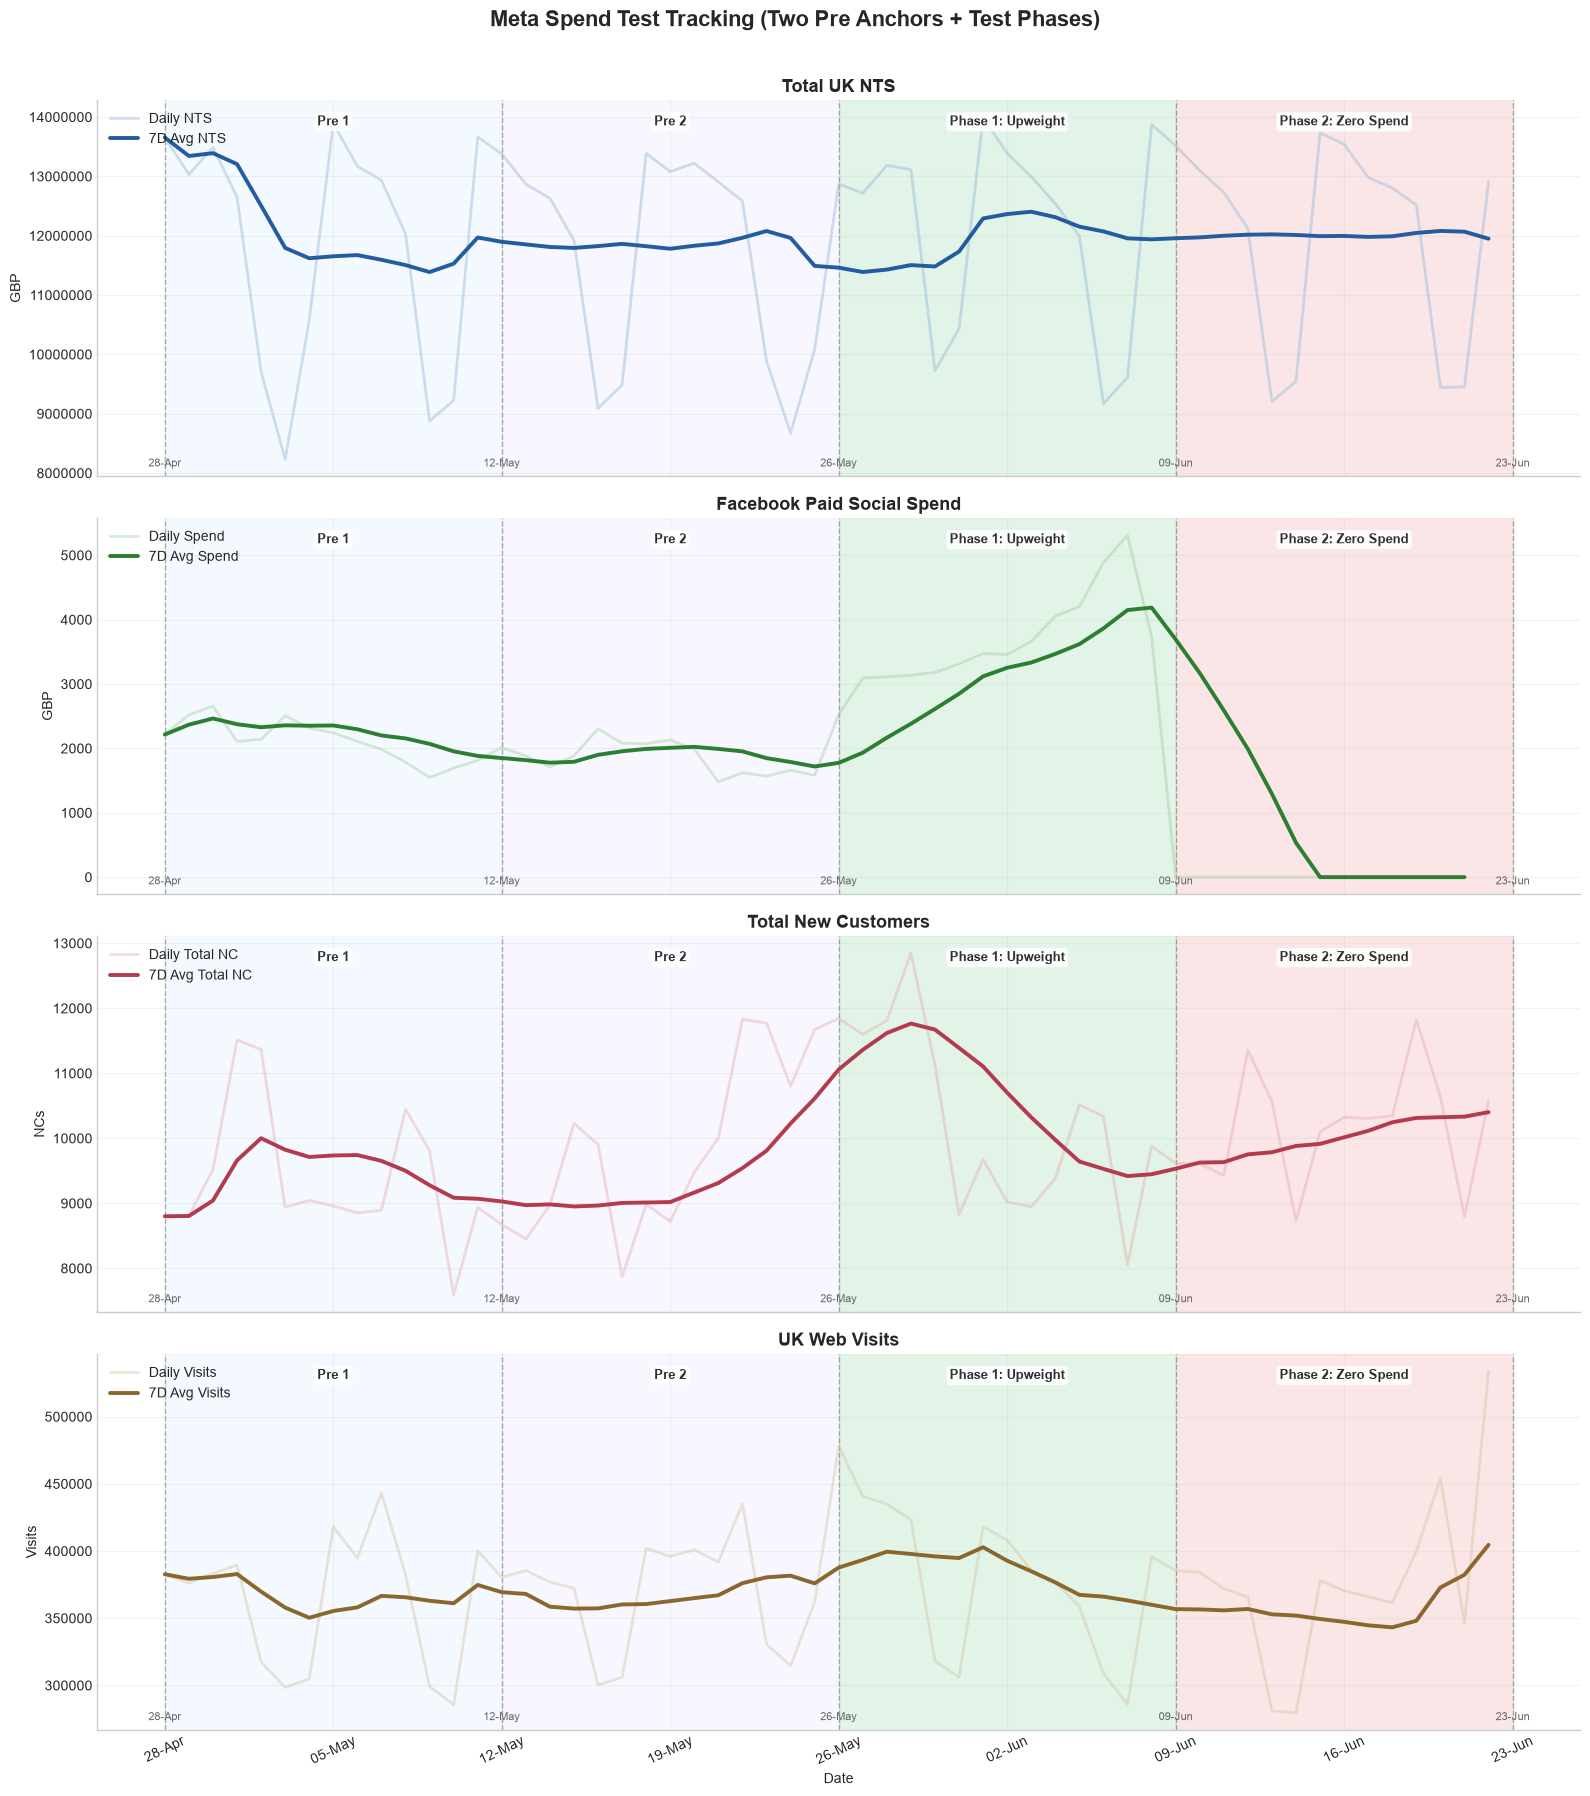


=== WEEK-ALIGNED SUMMARY (sums) ===


,week_index,total_nts_gbp,facebook_paid_social_spend_gbp,web_paid_social_new_customers,visits,total_new_customers
0,-4,"81,339,782.42","16,465.07","1,432.00",2452285,"67,993.00"
1,-3,"83,785,116.25","13,179.63","1,412.00",2623282,"63,492.00"
2,-2,"82,760,595.73","13,944.73","1,377.00",2523680,"63,087.00"
3,-1,"80,434,725.14","12,030.88","1,623.00",2631439,"74,288.00"
4,0,"86,036,315.93","21,832.56","1,945.00",2819666,"77,735.00"
5,1,"83,569,393.12","29,309.52","1,723.00",2519959,"66,134.00"
6,2,"83,945,837.96",0.00,"1,401.00",2445986,"69,401.14"
7,3,"83,646,237.72",0.00,"1,262.00",2832308,"72,814.00"


In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------
# 1) INPUT
# --------------------------------------------------
# Use the rebuilt df_analysis with full date range (2025-01-01 onwards)
df = df_analysis.copy()

# Make sure activity_date is datetime
df["activity_date"] = pd.to_datetime(df["activity_date"])

# ---------------------------------------------------
# 2) KEY TEST DATES + TWO PRE ANCHOR WINDOWS
# ---------------------------------------------------
pre_1_start = pd.Timestamp("2026-04-28")
pre_1_end   = pd.Timestamp("2026-05-11")

pre_2_start = pd.Timestamp("2026-05-12")
pre_2_end   = pd.Timestamp("2026-05-25")

upweight_date = pd.Timestamp("2026-05-26")   # Meta Web spend upweighted 2x
zero_date     = pd.Timestamp("2026-06-09")   # Meta Web spend downweighted to 0%
restore_date  = pd.Timestamp("2026-06-23")   # Meta Web spend restored to normal

# ---------------------------------------------------
# 3) PERIOD LABELS
# ---------------------------------------------------
def label_period(d):
    if pre_1_start <= d <= pre_1_end:
        return "Pre 1"
    elif pre_2_start <= d <= pre_2_end:
        return "Pre 2"
    elif upweight_date <= d < zero_date:
        return "Upweight"
    elif zero_date <= d < restore_date:
        return "Zero spend"
    elif d >= restore_date:
        return "Restored"
    return np.nan

df["period"] = df["activity_date"].apply(label_period)

# Keep only anchors + test periods + restored
df = df[df["period"].notna()].copy()

period_order = ["Pre 1", "Pre 2", "Upweight", "Zero spend", "Restored"]
df["period"] = pd.Categorical(df["period"], categories=period_order, ordered=True)

# ---------------------------------------------------
# 4) METRICS TO SUM / AVERAGE
# ---------------------------------------------------
sum_cols = [
    "total_nts_gbp",
    "facebook_paid_social_spend_gbp",
    "web_paid_social_scaled_nts_gbp",
    "web_direct_scaled_nts_gbp",
    "web_paid_social_new_customers",
    "web_direct_new_customers",
    "total_new_customers",
    "visits",
]

avg_cols = []

# ---------------------------------------------------
# 5) PERIOD SUMMARY
# ---------------------------------------------------
summary = (
    df.groupby("period", observed=True)[sum_cols + avg_cols]
      .agg({
          **{c: "sum" for c in sum_cols},
          **{c: "mean" for c in avg_cols},
      })
      .reset_index()
)

# Add days in period
days_in_period = df.groupby("period", observed=True).size().reset_index(name="days")
summary = summary.merge(days_in_period, on="period", how="left")

# Convert totals to daily averages for readability
for c in sum_cols:
    summary[f"avg_daily_{c}"] = summary[c] / summary["days"]

# ---------------------------------------------------
# 6) BASELINE COMPARISON VS TWO PRE ANCHORS
# ---------------------------------------------------
pre_1 = summary.loc[summary["period"] == "Pre 1"]
pre_2 = summary.loc[summary["period"] == "Pre 2"]

if pre_1.empty or pre_2.empty:
    raise ValueError("Missing Pre 1 or Pre 2 data. Check date coverage and period windows.")

pre_1 = pre_1.iloc[0]
pre_2 = pre_2.iloc[0]

# Combined anchor = mean of Pre 1 and Pre 2 daily averages
anchor = {f"avg_daily_{c}": np.mean([pre_1[f"avg_daily_{c}"], pre_2[f"avg_daily_{c}"]]) for c in sum_cols}
anchor = pd.Series(anchor)

compare_cols = [
    "total_nts_gbp",
    "facebook_paid_social_spend_gbp",
    "web_paid_social_scaled_nts_gbp",
    "web_direct_scaled_nts_gbp",
    "web_paid_social_new_customers",
    "web_direct_new_customers",
    "total_new_customers",
    "visits",
]

impact_rows = []
for _, row in summary.iterrows():
    if row["period"] in ["Pre 1", "Pre 2"]:
        continue

    out = {"period": row["period"], "days": row["days"]}

    for c in compare_cols:
        cur_avg = row[f"avg_daily_{c}"]
        pre_1_avg = pre_1[f"avg_daily_{c}"]
        pre_2_avg = pre_2[f"avg_daily_{c}"]
        anchor_avg = anchor[f"avg_daily_{c}"]

        out[f"{c}_avg_daily"] = cur_avg

        out[f"{c}_pct_change_vs_pre_1"] = (cur_avg / pre_1_avg - 1) if pd.notna(pre_1_avg) and pre_1_avg != 0 else np.nan
        out[f"{c}_pct_change_vs_pre_2"] = (cur_avg / pre_2_avg - 1) if pd.notna(pre_2_avg) and pre_2_avg != 0 else np.nan
        out[f"{c}_pct_change_vs_anchor"] = (cur_avg / anchor_avg - 1) if pd.notna(anchor_avg) and anchor_avg != 0 else np.nan

    impact_rows.append(out)

impact = pd.DataFrame(impact_rows)

# ---------------------------------------------------
# 7) CLEAN OUTPUT TABLES
# ---------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

display_cols = [
    "period", "days",
    "avg_daily_total_nts_gbp",
    "avg_daily_facebook_paid_social_spend_gbp",
    "avg_daily_web_paid_social_scaled_nts_gbp",
    "avg_daily_web_direct_scaled_nts_gbp",
    "avg_daily_web_paid_social_new_customers",
    "avg_daily_web_direct_new_customers",
    "avg_daily_total_new_customers",
    "avg_daily_visits",
]

display_cols = [c for c in display_cols if c in summary.columns]

print("=== PERIOD SUMMARY (daily averages) ===")
display(summary[display_cols].sort_values("period"))

print("\n=== CHANGE VS TWO PRE ANCHORS (daily averages) ===")
impact_display_cols = ["period", "days"] + [c for c in impact.columns if c.endswith("_pct_change_vs_anchor")]
impact_display_cols = [c for c in impact_display_cols if c in impact.columns]
display(impact[impact_display_cols])

print("\nAnchor definition: Anchor = average of Pre 1 and Pre 2 daily averages")

# ---------------------------------------------------
# 8) SIMPLE TEXT INSIGHTS (vs combined anchor)
# ---------------------------------------------------
def pct(x):
    return f"{x*100:.1f}%" if pd.notna(x) else "n/a"

anchor_nts = anchor["avg_daily_total_nts_gbp"]
anchor_nc = anchor["avg_daily_total_new_customers"]
anchor_spend = anchor["avg_daily_facebook_paid_social_spend_gbp"]

for period_name in ["Upweight", "Zero spend", "Restored"]:
    row = summary.loc[summary["period"] == period_name]
    if row.empty:
        continue

    row = row.iloc[0]
    nts_change = (row["avg_daily_total_nts_gbp"] / anchor_nts - 1) if anchor_nts else np.nan
    nc_change = (row["avg_daily_total_new_customers"] / anchor_nc - 1) if anchor_nc else np.nan
    spend_change = (row["avg_daily_facebook_paid_social_spend_gbp"] / anchor_spend - 1) if anchor_spend else np.nan

    print(
        f"{period_name}: NTS {pct(nts_change)} vs anchor, "
        f"Total NCs {pct(nc_change)} vs anchor, "
        f"Meta spend {pct(spend_change)} vs anchor."
    )

# ---------------------------------------------------
# 9) PLOTS (enhanced with phase labels on all axes + date boundaries + visible daily lines)
# ---------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")

df = df.sort_values("activity_date").copy()
df["nts_7d"] = df["total_nts_gbp"].rolling(7, min_periods=1).mean()
df["nc_7d"] = df["total_new_customers"].rolling(7, min_periods=1).mean()
df["spend_7d"] = df["facebook_paid_social_spend_gbp"].rolling(7, min_periods=1).mean()
df["visits_7d"] = df["visits"].rolling(7, min_periods=1).mean()

# Focus plotting window to pre-anchor onwards
plot_start = pre_1_start
df_plot = df[df["activity_date"] >= plot_start].copy()

test_windows = [
    {"label": "Pre 1", "start": pre_1_start, "end": pre_1_end + pd.Timedelta(days=1), "color": "#eef5ff"},
    {"label": "Pre 2", "start": pre_2_start, "end": pre_2_end + pd.Timedelta(days=1), "color": "#f4f0ff"},
    {"label": "Phase 1: Upweight", "start": upweight_date, "end": zero_date, "color": "#cdeed8"},
    {"label": "Phase 2: Zero Spend", "start": zero_date, "end": restore_date, "color": "#f7d6d6"},
]

def add_test_window_shading(ax):
    for w in test_windows:
        ax.axvspan(w["start"], w["end"], color=w["color"], alpha=0.6, zorder=0)

def add_phase_labels(ax):
    """Add phase labels and date boundaries to each subplot."""
    ymin, ymax = ax.get_ylim()
    y = ymax - 0.04 * (ymax - ymin)

    # Add phase labels
    for w in test_windows:
        x = w["start"] + (w["end"] - w["start"]) / 2
        ax.text(
            x,
            y,
            w["label"],
            ha="center",
            va="top",
            fontsize=9,
            fontweight="bold",
            color="#2f2f2f",
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        )

    # Add vertical lines at phase boundaries with date labels
    boundary_dates = [
        (pre_1_start, "28-Apr"),
        (pre_2_start, "12-May"),
        (upweight_date, "26-May"),
        (zero_date, "09-Jun"),
        (restore_date, "23-Jun"),
    ]
    for date, label in boundary_dates:
        ax.axvline(date, linestyle="--", linewidth=1.0, color="#666666", alpha=0.5, zorder=1)
        # Add date label below the line
        ymin_val, ymax_val = ax.get_ylim()
        ax.text(
            date,
            ymin_val + 0.02 * (ymax_val - ymin_val),
            label,
            ha="center",
            va="bottom",
            fontsize=8,
            color="#666666",
            rotation=0,
        )

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

axes[0].plot(df_plot["activity_date"], df_plot["total_nts_gbp"], alpha=0.40, lw=2.0, color="#8eb2d6", label="Daily NTS")
axes[0].plot(df_plot["activity_date"], df_plot["nts_7d"], lw=2.8, color="#235c9f", label="7D Avg NTS")
axes[0].set_title("Total UK NTS", fontsize=13, fontweight="bold")
axes[0].set_ylabel("GBP")
axes[0].legend(loc="upper left")

axes[1].plot(df_plot["activity_date"], df_plot["facebook_paid_social_spend_gbp"], alpha=0.40, lw=2.0, color="#9ecb9e", label="Daily Spend")
axes[1].plot(df_plot["activity_date"], df_plot["spend_7d"], lw=2.8, color="#2c7f30", label="7D Avg Spend")
axes[1].set_title("Facebook Paid Social Spend", fontsize=13, fontweight="bold")
axes[1].set_ylabel("GBP")
axes[1].legend(loc="upper left")

axes[2].plot(df_plot["activity_date"], df_plot["total_new_customers"], alpha=0.40, lw=2.0, color="#e3a7af", label="Daily Total NC")
axes[2].plot(df_plot["activity_date"], df_plot["nc_7d"], lw=2.8, color="#b33b4d", label="7D Avg Total NC")
axes[2].set_title("Total New Customers", fontsize=13, fontweight="bold")
axes[2].set_ylabel("NCs")
axes[2].legend(loc="upper left")

axes[3].plot(df_plot["activity_date"], df_plot["visits"], alpha=0.40, lw=2.0, color="#d3bf9f", label="Daily Visits")
axes[3].plot(df_plot["activity_date"], df_plot["visits_7d"], lw=2.8, color="#8a682d", label="7D Avg Visits")
axes[3].set_title("UK Web Visits", fontsize=13, fontweight="bold")
axes[3].set_ylabel("Visits")
axes[3].legend(loc="upper left")

for ax in axes:
    add_test_window_shading(ax)
    add_phase_labels(ax)
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)

fig.suptitle("Meta Spend Test Tracking (Two Pre Anchors + Test Phases)", fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

# ---------------------------------------------------
# 10) OPTIONAL: WEEK-ALIGNED VIEW
# ---------------------------------------------------
df["week_index"] = ((df["activity_date"] - upweight_date).dt.days // 7)

week_summary = (
    df.groupby("week_index")[[
        "total_nts_gbp",
        "facebook_paid_social_spend_gbp",
        "web_paid_social_new_customers",
        "visits",
        "total_new_customers",
    ]]
    .sum()
    .reset_index()
)

print("\n=== WEEK-ALIGNED SUMMARY (sums) ===")
display(week_summary)

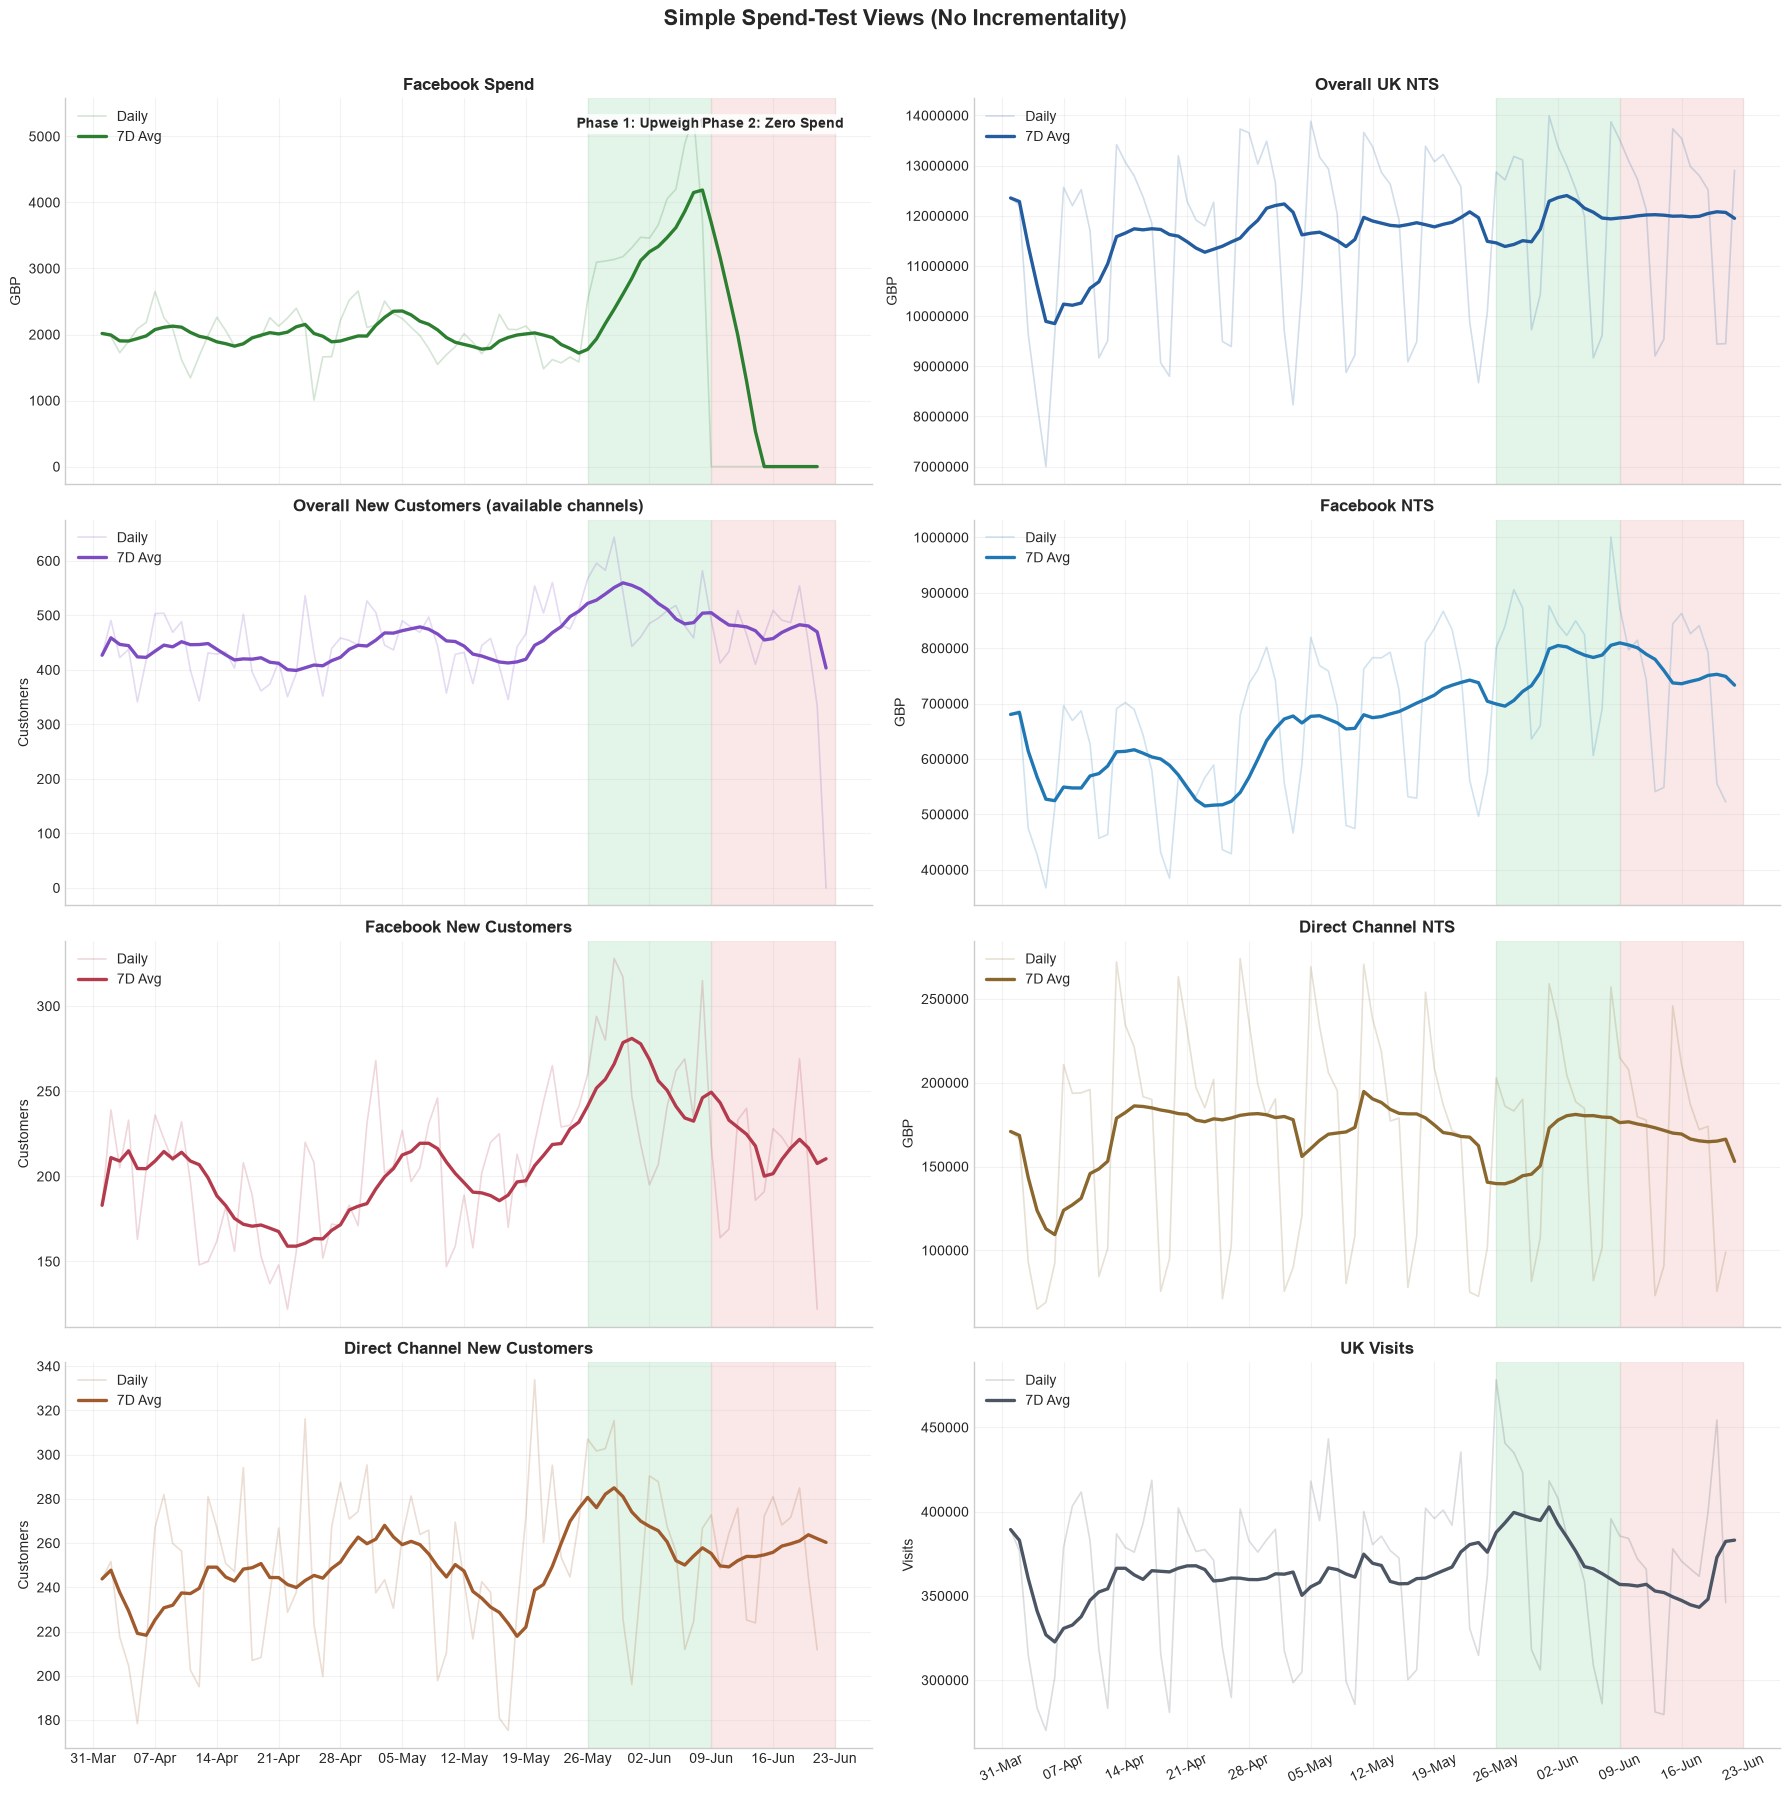

In [59]:
# Metrics: Spend, Total UK NTS, Overall New Customers, Facebook NTS/NC,
# Direct NTS/NC, and UK Visits

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Source frame
simple = df_analysis.copy()
simple["activity_date"] = pd.to_datetime(simple["activity_date"])

# Focus on the spend-test window context
simple = simple[simple["activity_date"] >= pd.Timestamp("2026-04-01")].copy()
simple = simple.sort_values("activity_date")

# Total NC already in dataframe
if "total_new_customers" not in simple.columns:
    simple["total_new_customers"] = (
        simple.get("web_paid_social_new_customers", 0).fillna(0)
        + simple.get("web_direct_new_customers", 0).fillna(0)
    )

# Use scaled NTS columns
simple["facebook_nts_gbp"] = simple["web_paid_social_scaled_nts_gbp"]
simple["direct_nts_gbp"] = simple["web_direct_scaled_nts_gbp"]

metric_specs = [
    ("facebook_paid_social_spend_gbp", "Facebook Spend", "GBP", "#2c7f30"),
    ("total_nts_gbp", "Total UK NTS", "GBP", "#235c9f"),
    ("total_new_customers", "Total New Customers", "Customers", "#7d4cc2"),
    ("facebook_nts_gbp", "Facebook NTS", "GBP", "#1f77b4"),
    ("web_paid_social_new_customers", "Facebook New Customers", "Customers", "#b33b4d"),
    ("direct_nts_gbp", "Direct Channel NTS", "GBP", "#8a682d"),
    ("web_direct_new_customers", "Direct Channel New Customers", "Customers", "#a05a2c"),
    ("visits", "UK Visits", "Visits", "#4b5563"),
]

# Keep only metrics that exist and have at least one non-null value
available_specs = []
for col, title, ylabel, color in metric_specs:
    if col in simple.columns and simple[col].notna().any():
        available_specs.append((col, title, ylabel, color))

if not available_specs:
    print("No requested metrics available in df_analysis for plotting.")
else:
    # Rolling smooth lines for readability
    for col, _, _, _ in available_specs:
        simple[f"{col}_7d"] = simple[col].rolling(7, min_periods=1).mean()

    fig, axes = plt.subplots(4, 2, figsize=(18, 18), sharex=True)
    axes = axes.flatten()

    # Test windows
    windows = [
        (pd.Timestamp("2026-05-26"), pd.Timestamp("2026-06-09"), "Phase 1", "#cdeed8"),
        (pd.Timestamp("2026-06-09"), pd.Timestamp("2026-06-23"), "Phase 2", "#f7d6d6"),
    ]

    for i, (col, title, ylabel, color) in enumerate(available_specs):
        ax = axes[i]
        ax.plot(simple["activity_date"], simple[col], color=color, alpha=0.20, lw=1.2, label="Daily")
        ax.plot(simple["activity_date"], simple[f"{col}_7d"], color=color, lw=2.4, label="7D Avg")

        for start, end, _, shade in windows:
            ax.axvspan(start, end, color=shade, alpha=0.55, zorder=0)

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(loc="upper left")

    # Hide unused axes if fewer than 8 charts are available
    for j in range(len(available_specs), len(axes)):
        axes[j].axis("off")

    # One set of test labels on the first visible chart to reduce clutter
    first_ax = axes[0]
    ymin, ymax = first_ax.get_ylim()
    y = ymax - 0.05 * (ymax - ymin)
    first_ax.text(pd.Timestamp("2026-06-01"), y, "Phase 1: Upweight", ha="center", va="top", fontsize=10, fontweight="bold",
                  bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"})
    first_ax.text(pd.Timestamp("2026-06-16"), y, "Phase 2: Zero Spend", ha="center", va="top", fontsize=10, fontweight="bold",
                  bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"})

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))

    plt.xticks(rotation=25)
    fig.suptitle("Simple Spend-Test Views (With New Total Columns)", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

    missing_requested = [
        title for col, title, _, _ in metric_specs if col not in simple.columns
    ]
    if missing_requested:
        print("\nNot available in df_analysis:")
        for m in missing_requested:
            print(f"- {m}")

In [44]:
df_analysis

,activity_date,overall_nts_gbp,facebook_paid_social_spend_gbp,web_paid_social_nts_gbp,web_paid_social_scaled_nts_gbp,web_direct_nts_gbp,web_direct_scaled_nts_gbp,web_paid_social_new_customers,web_direct_new_customers,incremental_new_customers,incremental_nts_gbp,incremental_spend_gbp,incremental_iROAS_gbp,incremental_iCPA_gbp,visits
0,2025-01-01,"6,287,071.97","4,030.40","242,933.75","254,062.31","102,066.06","106,741.61",203.00,310.84,814.52,"94,431.85","20,252.27",4.66,24.86,"396,972.00"
1,2025-01-02,"9,313,804.28","4,094.57","343,087.99","361,767.91","200,181.00","211,080.14",235.00,445.80,998.73,"139,648.09","22,739.18",6.14,22.77,"475,153.00"
2,2025-01-03,"8,745,089.33","3,990.75","316,860.23","333,590.32","182,433.02","192,065.41",222.00,367.44,"1,011.31","128,226.66","23,194.46",5.53,22.94,"488,866.00"
3,2025-01-04,"6,752,054.56","4,102.99","259,386.79","270,904.56","92,554.20","96,663.96",184.00,322.32,770.46,"84,016.50","21,046.14",3.99,27.32,"380,637.00"
4,2025-01-05,"7,575,561.32","4,129.16","259,195.48","272,829.69","116,990.20","123,144.12",159.00,304.83,785.60,"100,360.36","23,297.91",4.31,29.66,"481,288.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533,2026-06-18,"12,803,514.40",NaN,"798,590.71","840,590.83","163,376.50","171,968.93",215.00,271.63,352.22,"29,047.36","24,998.66",1.16,70.97,"361,632.00"
534,2026-06-19,"12,517,154.94",NaN,"750,439.00","792,112.56","164,867.42","174,022.87",269.00,284.95,386.86,"28,822.40","24,620.10",1.17,63.64,"399,841.00"
535,2026-06-20,"9,443,171.66",NaN,"532,418.07","555,489.50","72,432.97","75,571.73",205.00,244.52,315.37,"20,277.95","16,690.76",1.21,52.92,"454,380.00"
536,2026-06-21,"9,451,803.55",NaN,"497,122.78","522,572.95","94,114.72","98,932.92",122.00,211.71,278.51,"18,689.31","17,440.15",1.07,62.62,"345,983.00"


# Comparitive Analysis starts from here

In [142]:
import pandas as pd
import numpy as np

df = df_analysis.copy()
df["activity_date"] = pd.to_datetime(df["activity_date"])

# Two pre-anchor windows + test windows
PRE1_START = "2026-04-28"
PRE1_END = "2026-05-11"

PRE2_START = "2026-05-12"
PRE2_END = "2026-05-25"

UP_START = "2026-05-26"
UP_END = "2026-06-08"

ZERO_START = "2026-06-09"
ZERO_END = "2026-06-22"

def assign_period(x):
    d = str(x.date())
    if PRE1_START <= d <= PRE1_END:
        return "Pre 1"
    elif PRE2_START <= d <= PRE2_END:
        return "Pre 2"
    elif UP_START <= d <= UP_END:
        return "Upweight"
    elif ZERO_START <= d <= ZERO_END:
        return "Zero"
    return np.nan

df["period"] = df["activity_date"].apply(assign_period)

# Filter to anchor + test periods only
test_df = df[df["period"].notna()].copy()

### Period Summary Table

In [143]:
metrics = [
    "facebook_paid_social_spend_gbp",
    "total_nts_gbp",
    "visits",
    "web_paid_social_scaled_nts_gbp",
    "web_direct_scaled_nts_gbp",
    "web_paid_social_new_customers",
    "web_direct_new_customers",
    "total_new_customers"
]

period_summary = (
    test_df
    .groupby("period")[metrics]
    .sum()
    .round(0)
)

period_summary

,facebook_paid_social_spend_gbp,total_nts_gbp,visits,web_paid_social_scaled_nts_gbp,web_direct_scaled_nts_gbp,web_paid_social_new_customers,web_direct_new_customers,total_new_customers
period,,,,,,,,
Pre 1,"29,645.00","165,124,899.00",5075567,"9,413,643.00","2,455,561.00","2,844.00","3,591.00","131,485.00"
Pre 2,"25,976.00","163,195,321.00",5155119,"9,883,835.00","2,237,623.00","3,000.00","3,455.00","137,375.00"
Upweight,"51,142.00","169,605,709.00",5339625,"11,228,012.00","2,465,173.00","3,668.00","3,694.00","143,869.00"
Zero,0.00,"167,592,076.00",5278294,"9,523,789.00","2,331,149.00","2,663.00","3,655.00","142,215.00"


### Change Table

In [144]:
metrics = [
    "facebook_paid_social_spend_gbp",
    "total_nts_gbp",
    "visits",
    "web_paid_social_scaled_nts_gbp",
    "web_direct_scaled_nts_gbp",
    "web_paid_social_new_customers",
    "web_direct_new_customers",
    "total_new_customers"
]

pre_1_avg = test_df[test_df["period"] == "Pre 1"][metrics].mean()
pre_2_avg = test_df[test_df["period"] == "Pre 2"][metrics].mean()
anchor_avg = (pre_1_avg + pre_2_avg) / 2

change_vs_anchor = []
for period_name in ["Upweight", "Zero"]:
    period_avg = test_df[test_df["period"] == period_name][metrics].mean()
    pct_change = (period_avg / anchor_avg - 1) * 100
    change_vs_anchor.append(pct_change)

pd.DataFrame(change_vs_anchor, index=["Upweight", "Zero"]).T.round(2)

,Upweight,Zero
facebook_paid_social_spend_gbp,83.90,-100.00
total_nts_gbp,3.32,2.09
visits,4.38,3.19
web_paid_social_scaled_nts_gbp,16.37,6.30
web_direct_scaled_nts_gbp,5.05,-0.66
web_paid_social_new_customers,25.53,-1.85
web_direct_new_customers,4.87,3.76
total_new_customers,7.02,5.79


In [149]:
upweight_avg = test_df[test_df["period"] == "Upweight"][metrics].mean()
zero_avg = test_df[test_df["period"] == "Zero"][metrics].mean()

incremental = ((upweight_avg / zero_avg) - 1) * 100

pd.DataFrame(
    {"Incremental": incremental}
).round(2)

,Incremental
facebook_paid_social_spend_gbp,inf
total_nts_gbp,1.20
visits,1.16
web_paid_social_scaled_nts_gbp,9.47
web_direct_scaled_nts_gbp,5.75
web_paid_social_new_customers,27.90
web_direct_new_customers,1.07
total_new_customers,1.16


In [152]:
upweight_avg = test_df[test_df["period"] == "Upweight"][metrics].mean()
zero_avg = test_df[test_df["period"] == "Zero"][metrics].mean()

pd.DataFrame({
    "Pre": anchor_avg,
    "Upweight": upweight_avg,
    "Upweight_Diff": upweight_avg - anchor_avg,
    "Upweight_%": (upweight_avg / anchor_avg - 1) * 100,
    "Zero": zero_avg,
    "Zero_Diff": zero_avg - anchor_avg,
    "Zero_%": (zero_avg / anchor_avg - 1) * 100,
}).round(2)

,Pre,Upweight,Upweight_Diff,Upweight_%,Zero,Zero_Diff,Zero_%
facebook_paid_social_spend_gbp,"1,986.44","3,653.01","1,666.57",83.90,0.00,"-1,986.44",-100.00
total_nts_gbp,"11,725,722.13","12,114,693.50","388,971.38",3.32,"11,970,862.55","245,140.42",2.09
visits,"365,381.64","381,401.79","16,020.14",4.38,"377,021.00","11,639.36",3.19
web_paid_social_scaled_nts_gbp,"689,195.65","802,000.86","112,805.22",16.37,"732,599.17","43,403.52",6.30
web_direct_scaled_nts_gbp,"167,613.73","176,083.79","8,470.06",5.05,"166,510.61","-1,103.12",-0.66
web_paid_social_new_customers,208.71,262.00,53.29,25.53,204.85,-3.87,-1.85
web_direct_new_customers,251.64,263.89,12.25,4.87,261.09,9.45,3.76
total_new_customers,"9,602.14","10,276.36",674.21,7.02,"10,158.22",556.08,5.79


# The Plotting

In [147]:
pre_1 = period_summary.loc["Pre 1"]
pre_2 = period_summary.loc["Pre 2"]
pre_anchor = (pre_1 + pre_2) / 2
up = period_summary.loc["Upweight"]

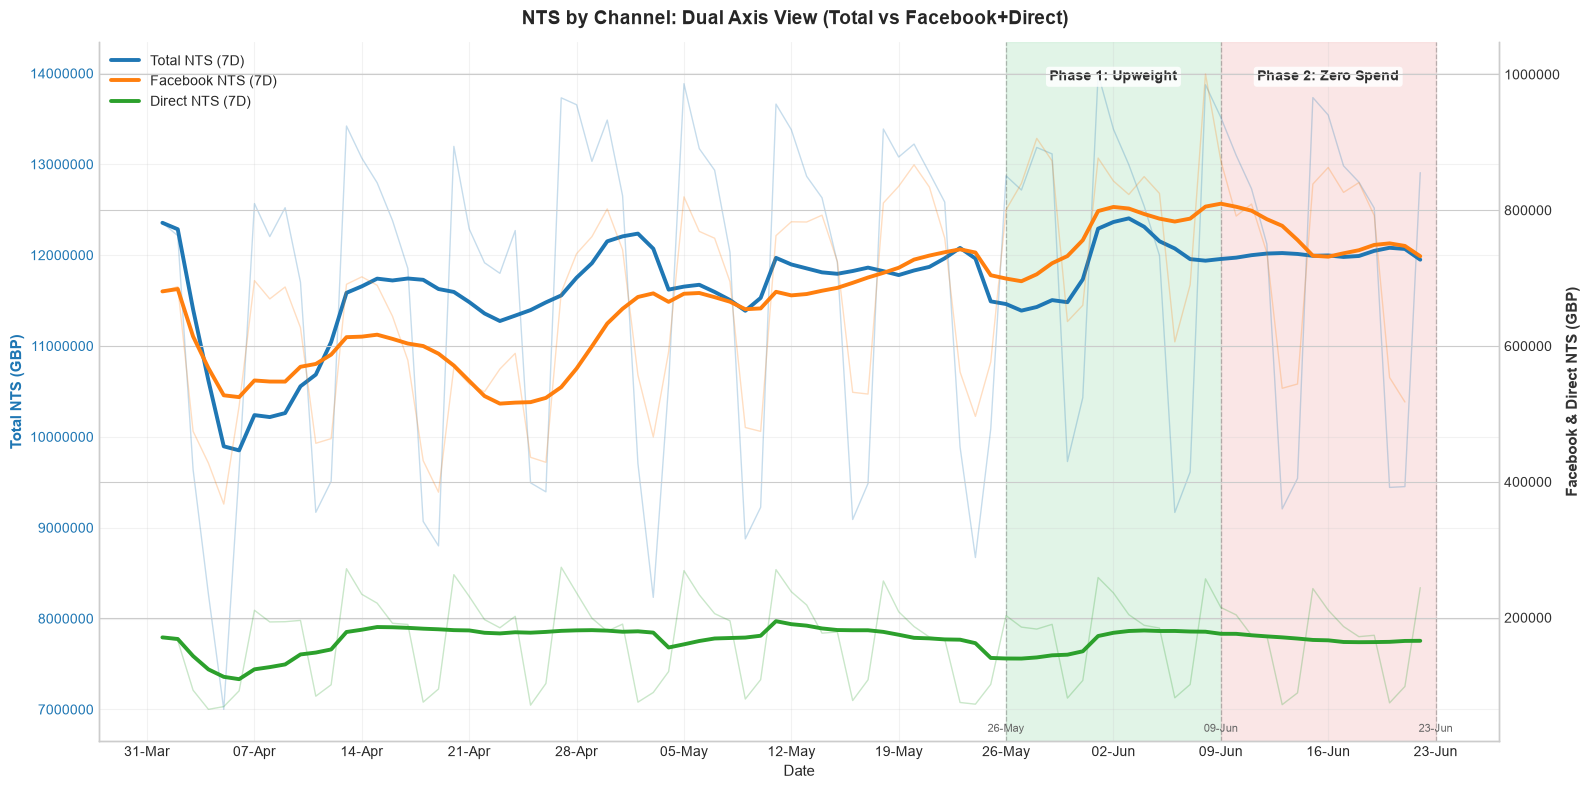


✅ Multi-channel NTS chart with dual y-axes - same graph, different scales!


In [129]:
plt.style.use("seaborn-v0_8-whitegrid")

# Prepare data for multi-channel NTS chart with dual y-axes
df_nts = df.sort_values("activity_date").copy()
df_nts = df_nts[df_nts["activity_date"] >= pd.Timestamp("2026-04-01")].copy()

# Calculate 7D rolling averages for each channel
df_nts["overall_nts_7d"] = df_nts["total_nts_gbp"].rolling(7, min_periods=1).mean()
df_nts["facebook_nts_7d"] = df_nts["web_paid_social_scaled_nts_gbp"].rolling(7, min_periods=1).mean()
df_nts["direct_nts_7d"] = df_nts["web_direct_scaled_nts_gbp"].rolling(7, min_periods=1).mean()

# Create figure with primary and secondary axes
fig, ax1 = plt.subplots(figsize=(16, 8))

# Define phase windows
phase_windows = [
    {"label": "Phase 1: Upweight", "start": upweight_date, "end": zero_date, "color": "#cdeed8"},
    {"label": "Phase 2: Zero Spend", "start": zero_date, "end": restore_date, "color": "#f7d6d6"},
]

# Add phase shading (behind all plots)
for w in phase_windows:
    ax1.axvspan(w["start"], w["end"], color=w["color"], alpha=0.6, zorder=0)

# --- PRIMARY AXIS (LEFT): Total NTS ---
ax1.plot(df_nts["activity_date"], df_nts["total_nts_gbp"], alpha=0.25, lw=1.0, color="#1f77b4")
line1 = ax1.plot(df_nts["activity_date"], df_nts["overall_nts_7d"], lw=2.8, color="#1f77b4", label="Total NTS (7D)", zorder=5)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Total NTS (GBP)", fontsize=11, color="#1f77b4", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(True, alpha=0.25)
ax1.spines["top"].set_visible(False)

# --- SECONDARY AXIS (RIGHT): Facebook & Direct NTS ---
ax2 = ax1.twinx()
line2 = ax2.plot(df_nts["activity_date"], df_nts["facebook_nts_7d"], lw=2.8, color="#ff7f0e", label="Facebook NTS (7D)", zorder=5)
line3 = ax2.plot(df_nts["activity_date"], df_nts["direct_nts_7d"], lw=2.8, color="#2ca02c", label="Direct NTS (7D)", zorder=5)
ax2.plot(df_nts["activity_date"], df_nts["web_paid_social_scaled_nts_gbp"], alpha=0.25, lw=1.0, color="#ff7f0e")
ax2.plot(df_nts["activity_date"], df_nts["web_direct_scaled_nts_gbp"], alpha=0.25, lw=1.0, color="#2ca02c")
ax2.set_ylabel("Facebook & Direct NTS (GBP)", fontsize=11, color="#333333", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#333333")
ax2.spines["top"].set_visible(False)

# Add phase labels
ymin, ymax = ax1.get_ylim()
y = ymax - 0.04 * (ymax - ymin)
for w in phase_windows:
    x = w["start"] + (w["end"] - w["start"]) / 2
    ax1.text(
        x,
        y,
        w["label"],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#2f2f2f",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        zorder=10,
    )

# Add vertical boundary lines
boundary_dates = [
    (upweight_date, "26-May"),
    (zero_date, "09-Jun"),
    (restore_date, "23-Jun"),
]
for date, label in boundary_dates:
    ax1.axvline(date, linestyle="--", linewidth=0.9, color="#666666", alpha=0.4, zorder=1)
    ymin_val, ymax_val = ax1.get_ylim()
    ax1.text(
        date,
        ymin_val + 0.01 * (ymax_val - ymin_val),
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#666666",
    )

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10, framealpha=0.95)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)

fig.suptitle("NTS by Channel: Dual Axis View (Total vs Facebook+Direct)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Multi-channel NTS chart with dual y-axes - same graph, different scales!")

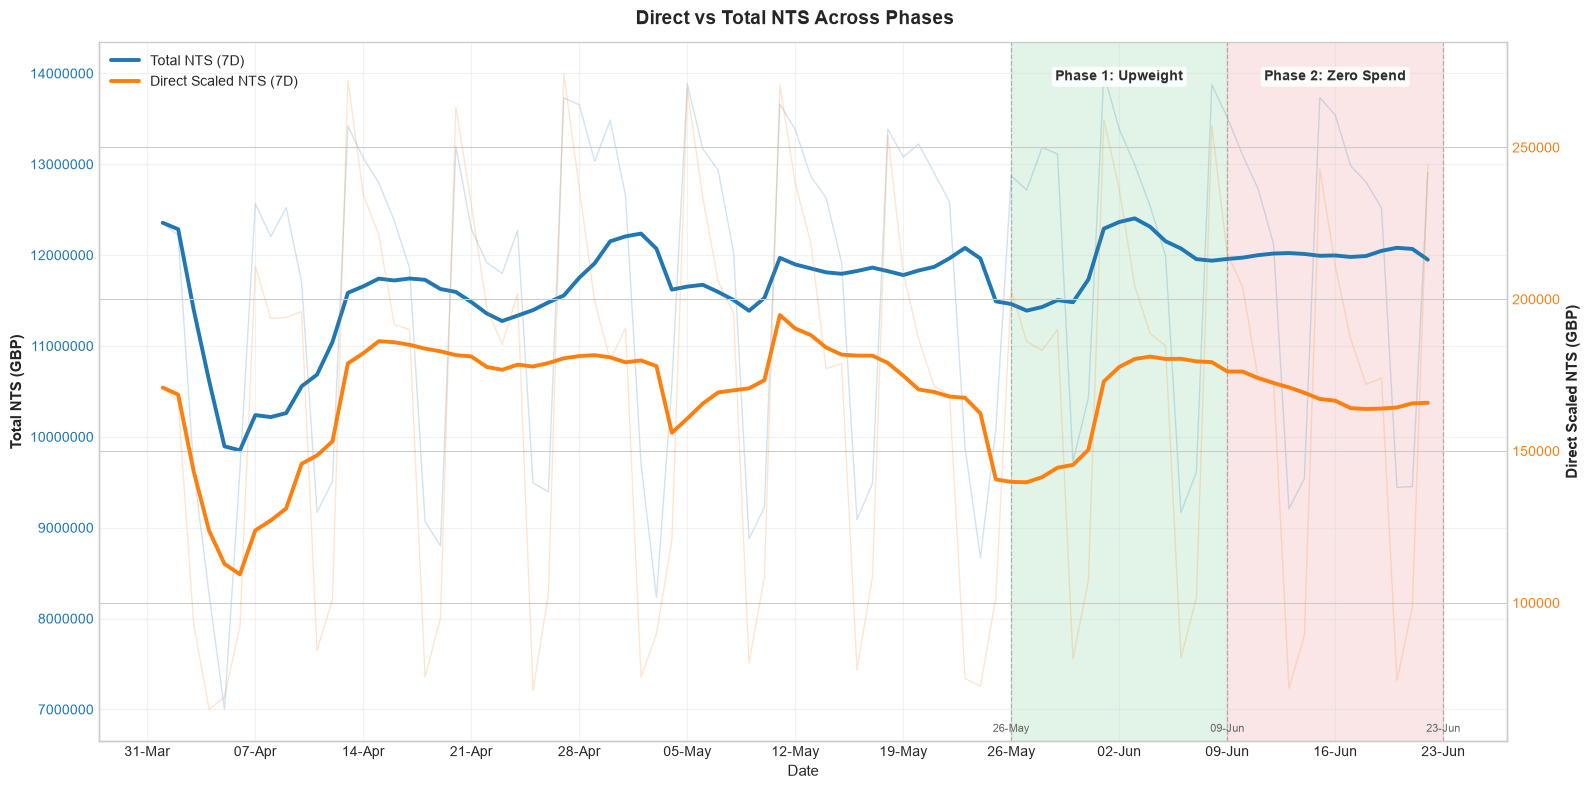


✅ Direct vs Total NTS dual-axis chart created!


In [131]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-whitegrid")

# Prepare data for Direct vs Total NTS chart (dual axis)
df_nts_dt = df.sort_values("activity_date").copy()
df_nts_dt = df_nts_dt[df_nts_dt["activity_date"] >= pd.Timestamp("2026-04-01")].copy()

# Calculate 7D rolling averages (use TOTAL NTS not overall)
df_nts_dt["total_nts_7d"] = df_nts_dt["total_nts_gbp"].rolling(7, min_periods=1).mean()
df_nts_dt["direct_nts_7d"] = df_nts_dt["web_direct_scaled_nts_gbp"].rolling(7, min_periods=1).mean()

# Create figure with primary and secondary axes
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Define phase windows
phase_windows = [
    {"label": "Phase 1: Upweight", "start": upweight_date, "end": zero_date, "color": "#cdeed8"},
    {"label": "Phase 2: Zero Spend", "start": zero_date, "end": restore_date, "color": "#f7d6d6"},
]

# Add phase shading (behind all plots)
for w in phase_windows:
    ax1.axvspan(w["start"], w["end"], color=w["color"], alpha=0.6, zorder=0)

# --- Primary Axis (Left): Total NTS ---
ax1.plot(df_nts_dt["activity_date"], df_nts_dt["total_nts_gbp"], alpha=0.2, lw=1.0, color="#1f77b4")
line1 = ax1.plot(df_nts_dt["activity_date"], df_nts_dt["total_nts_7d"], lw=2.8, color="#1f77b4", label="Total NTS (7D)")
ax1.set_ylabel("Total NTS (GBP)", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

# --- Secondary Axis (Right): Direct NTS ---
ax2.plot(df_nts_dt["activity_date"], df_nts_dt["web_direct_scaled_nts_gbp"], alpha=0.2, lw=1.0, color="#ff7f0e")
line2 = ax2.plot(df_nts_dt["activity_date"], df_nts_dt["direct_nts_7d"], lw=2.8, color="#ff7f0e", label="Direct Scaled NTS (7D)")
ax2.set_ylabel("Direct Scaled NTS (GBP)", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")

# --- Formatting ---
ax1.set_xlabel("Date", fontsize=11)
ax1.grid(True, alpha=0.25)
ax1.spines["top"].set_visible(False)

# Add phase labels
ymin, ymax = ax1.get_ylim()
y = ymax - 0.04 * (ymax - ymin)
for w in phase_windows:
    x = w["start"] + (w["end"] - w["start"]) / 2
    ax1.text(
        x,
        y,
        w["label"],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#2f2f2f",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        zorder=10,
    )

# Add vertical boundary lines
boundary_dates = [
    (upweight_date, "26-May"),
    (zero_date, "09-Jun"),
    (restore_date, "23-Jun"),
]
for date, label in boundary_dates:
    ax1.axvline(date, linestyle="--", linewidth=0.9, color="#666666", alpha=0.4, zorder=1)
    ymin_val, ymax_val = ax1.get_ylim()
    ax1.text(
        date,
        ymin_val + 0.01 * (ymax_val - ymin_val),
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#666666",
    )

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10, framealpha=0.95)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)

fig.suptitle("Direct vs Total NTS Across Phases", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Direct vs Total NTS dual-axis chart created!")

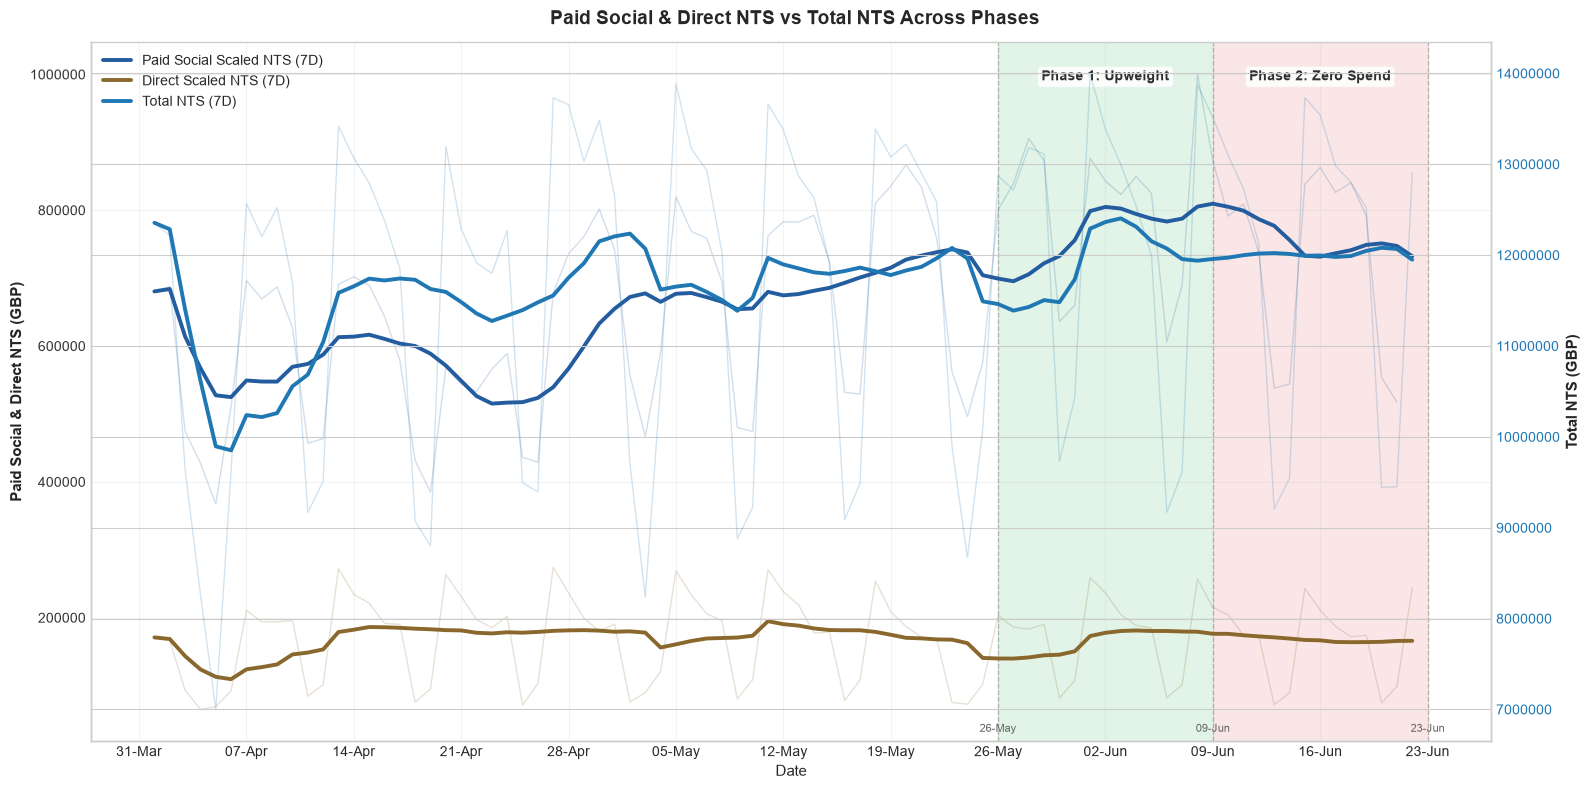


✅ Paid Social & Direct vs Total NTS dual-axis chart created!


In [136]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-whitegrid")

# Prepare data for Paid Social & Direct vs Total NTS chart (dual axis)
df_nts_st = df.sort_values("activity_date").copy()
df_nts_st = df_nts_st[df_nts_st["activity_date"] >= pd.Timestamp("2026-04-01")].copy()

# Calculate 7D rolling averages
df_nts_st["total_nts_7d"] = df_nts_st["total_nts_gbp"].rolling(7, min_periods=1).mean()
df_nts_st["social_nts_7d"] = df_nts_st["web_paid_social_scaled_nts_gbp"].rolling(7, min_periods=1).mean()
df_nts_st["direct_nts_7d"] = df_nts_st["web_direct_scaled_nts_gbp"].rolling(7, min_periods=1).mean()

# Create figure with primary and secondary axes
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Define phase windows
phase_windows = [
    {"label": "Phase 1: Upweight", "start": upweight_date, "end": zero_date, "color": "#cdeed8"},
    {"label": "Phase 2: Zero Spend", "start": zero_date, "end": restore_date, "color": "#f7d6d6"},
]

# Add phase shading (behind all plots)
for w in phase_windows:
    ax1.axvspan(w["start"], w["end"], color=w["color"], alpha=0.6, zorder=0)

# --- Primary Axis (Left): Paid Social & Direct NTS ---
ax1.plot(df_nts_st["activity_date"], df_nts_st["web_paid_social_scaled_nts_gbp"], alpha=0.2, lw=1.0, color="#235c9f")
line1 = ax1.plot(df_nts_st["activity_date"], df_nts_st["social_nts_7d"], lw=2.8, color="#235c9f", label="Paid Social Scaled NTS (7D)")

ax1.plot(df_nts_st["activity_date"], df_nts_st["web_direct_scaled_nts_gbp"], alpha=0.2, lw=1.0, color="#8a682d")
line2 = ax1.plot(df_nts_st["activity_date"], df_nts_st["direct_nts_7d"], lw=2.8, color="#8a682d", label="Direct Scaled NTS (7D)")

ax1.set_ylabel("Paid Social & Direct NTS (GBP)", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#333333")

# --- Secondary Axis (Right): Total NTS ---
ax2.plot(df_nts_st["activity_date"], df_nts_st["total_nts_gbp"], alpha=0.2, lw=1.0, color="#1f77b4")
line3 = ax2.plot(df_nts_st["activity_date"], df_nts_st["total_nts_7d"], lw=2.8, color="#1f77b4", label="Total NTS (7D)")
ax2.set_ylabel("Total NTS (GBP)", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

# --- Formatting ---
ax1.set_xlabel("Date", fontsize=11)
ax1.grid(True, alpha=0.25)
ax1.spines["top"].set_visible(False)

# Add phase labels
ymin, ymax = ax1.get_ylim()
y = ymax - 0.04 * (ymax - ymin)
for w in phase_windows:
    x = w["start"] + (w["end"] - w["start"]) / 2
    ax1.text(
        x,
        y,
        w["label"],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#2f2f2f",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        zorder=10,
    )

# Add vertical boundary lines
boundary_dates = [
    (upweight_date, "26-May"),
    (zero_date, "09-Jun"),
    (restore_date, "23-Jun"),
]
for date, label in boundary_dates:
    ax1.axvline(date, linestyle="--", linewidth=0.9, color="#666666", alpha=0.4, zorder=1)
    ymin_val, ymax_val = ax1.get_ylim()
    ax1.text(
        date,
        ymin_val + 0.01 * (ymax_val - ymin_val),
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#666666",
    )

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10, framealpha=0.95)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)

fig.suptitle("Paid Social & Direct NTS vs Total NTS Across Phases", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Paid Social & Direct vs Total NTS dual-axis chart created!")

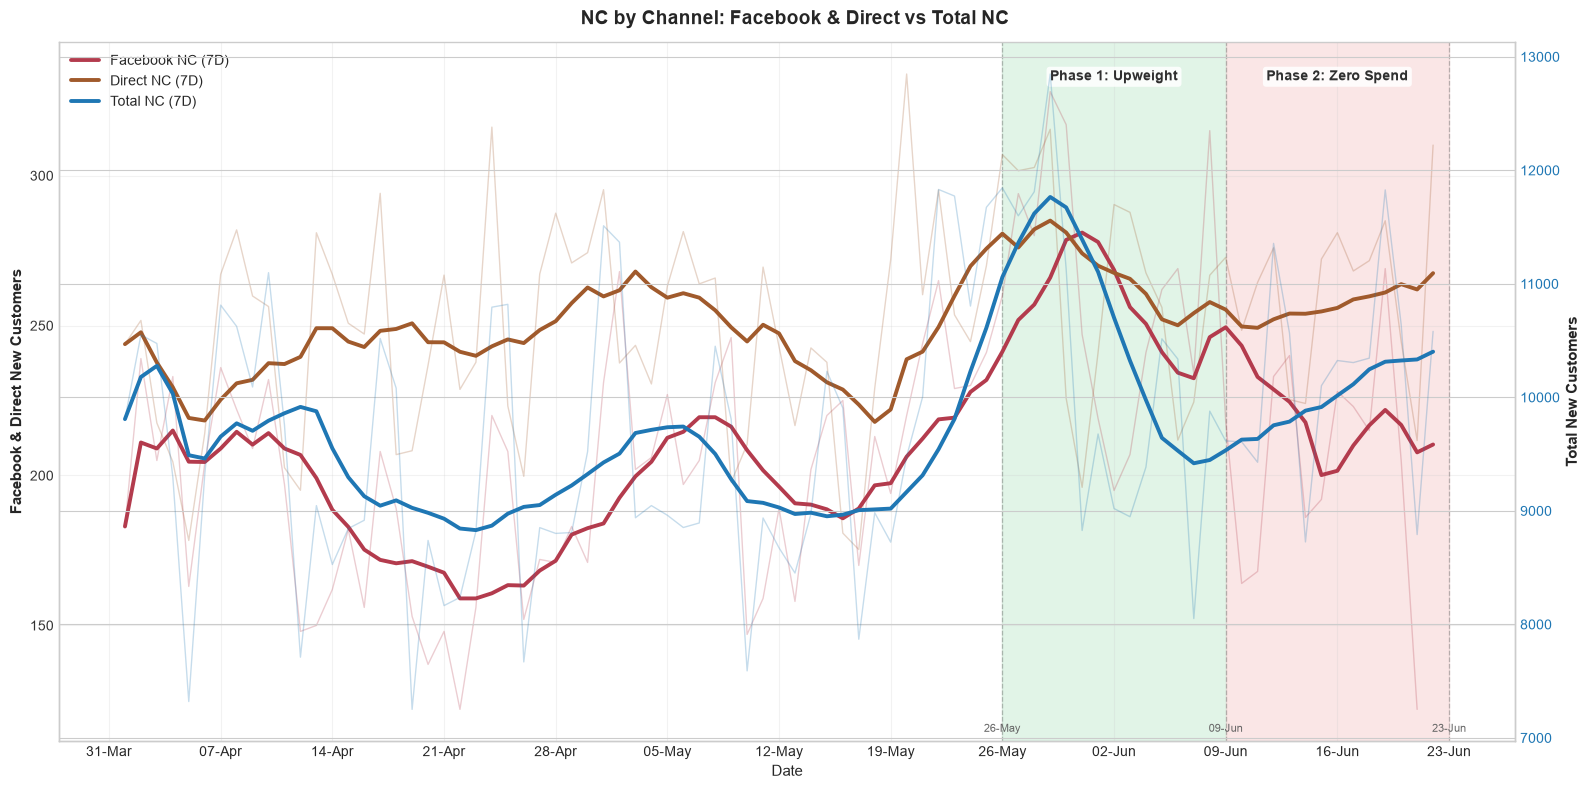


✅ Multi-channel NC chart created!


In [137]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-whitegrid")

# Prepare data for multi-channel NC chart (dual axis)
df_nc = df.sort_values("activity_date").copy()
df_nc = df_nc[df_nc["activity_date"] >= pd.Timestamp("2026-04-01")].copy()

# Calculate 7D rolling averages for each channel
df_nc["total_nc_7d"] = df_nc["total_new_customers"].rolling(7, min_periods=1).mean()
df_nc["facebook_nc_7d"] = df_nc["web_paid_social_new_customers"].rolling(7, min_periods=1).mean()
df_nc["direct_nc_7d"] = df_nc["web_direct_new_customers"].rolling(7, min_periods=1).mean()

# Create figure with dual axes
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Define phase windows
phase_windows = [
    {"label": "Phase 1: Upweight", "start": upweight_date, "end": zero_date, "color": "#cdeed8"},
    {"label": "Phase 2: Zero Spend", "start": zero_date, "end": restore_date, "color": "#f7d6d6"},
]

# Add phase shading (behind all plots)
for w in phase_windows:
    ax1.axvspan(w["start"], w["end"], color=w["color"], alpha=0.6, zorder=0)

# --- Primary Axis (Left): Facebook & Direct NC ---
ax1.plot(df_nc["activity_date"], df_nc["web_paid_social_new_customers"], alpha=0.25, lw=1.0, color="#b33b4d")
line1 = ax1.plot(df_nc["activity_date"], df_nc["facebook_nc_7d"], lw=2.8, color="#b33b4d", label="Facebook NC (7D)", zorder=5)

ax1.plot(df_nc["activity_date"], df_nc["web_direct_new_customers"], alpha=0.25, lw=1.0, color="#a05a2c")
line2 = ax1.plot(df_nc["activity_date"], df_nc["direct_nc_7d"], lw=2.8, color="#a05a2c", label="Direct NC (7D)", zorder=5)

ax1.set_ylabel("Facebook & Direct New Customers", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#333333")

# --- Secondary Axis (Right): Total NC ---
ax2.plot(df_nc["activity_date"], df_nc["total_new_customers"], alpha=0.25, lw=1.0, color="#1f77b4")
line3 = ax2.plot(df_nc["activity_date"], df_nc["total_nc_7d"], lw=2.8, color="#1f77b4", label="Total NC (7D)", zorder=5)
ax2.set_ylabel("Total New Customers", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

ax1.set_xlabel("Date", fontsize=11)
ax1.grid(True, alpha=0.25)
ax1.spines["top"].set_visible(False)

# Add phase labels
ymin, ymax = ax1.get_ylim()
y = ymax - 0.04 * (ymax - ymin)
for w in phase_windows:
    x = w["start"] + (w["end"] - w["start"]) / 2
    ax1.text(
        x,
        y,
        w["label"],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#2f2f2f",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        zorder=10,
    )

# Add vertical boundary lines
boundary_dates = [
    (upweight_date, "26-May"),
    (zero_date, "09-Jun"),
    (restore_date, "23-Jun"),
]
for date, label in boundary_dates:
    ax1.axvline(date, linestyle="--", linewidth=0.9, color="#666666", alpha=0.4, zorder=1)
    ymin_val, ymax_val = ax1.get_ylim()
    ax1.text(
        date,
        ymin_val + 0.01 * (ymax_val - ymin_val),
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#666666",
    )

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10, framealpha=0.95)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)

fig.suptitle("NC by Channel: Facebook & Direct vs Total NC", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Multi-channel NC chart created!")

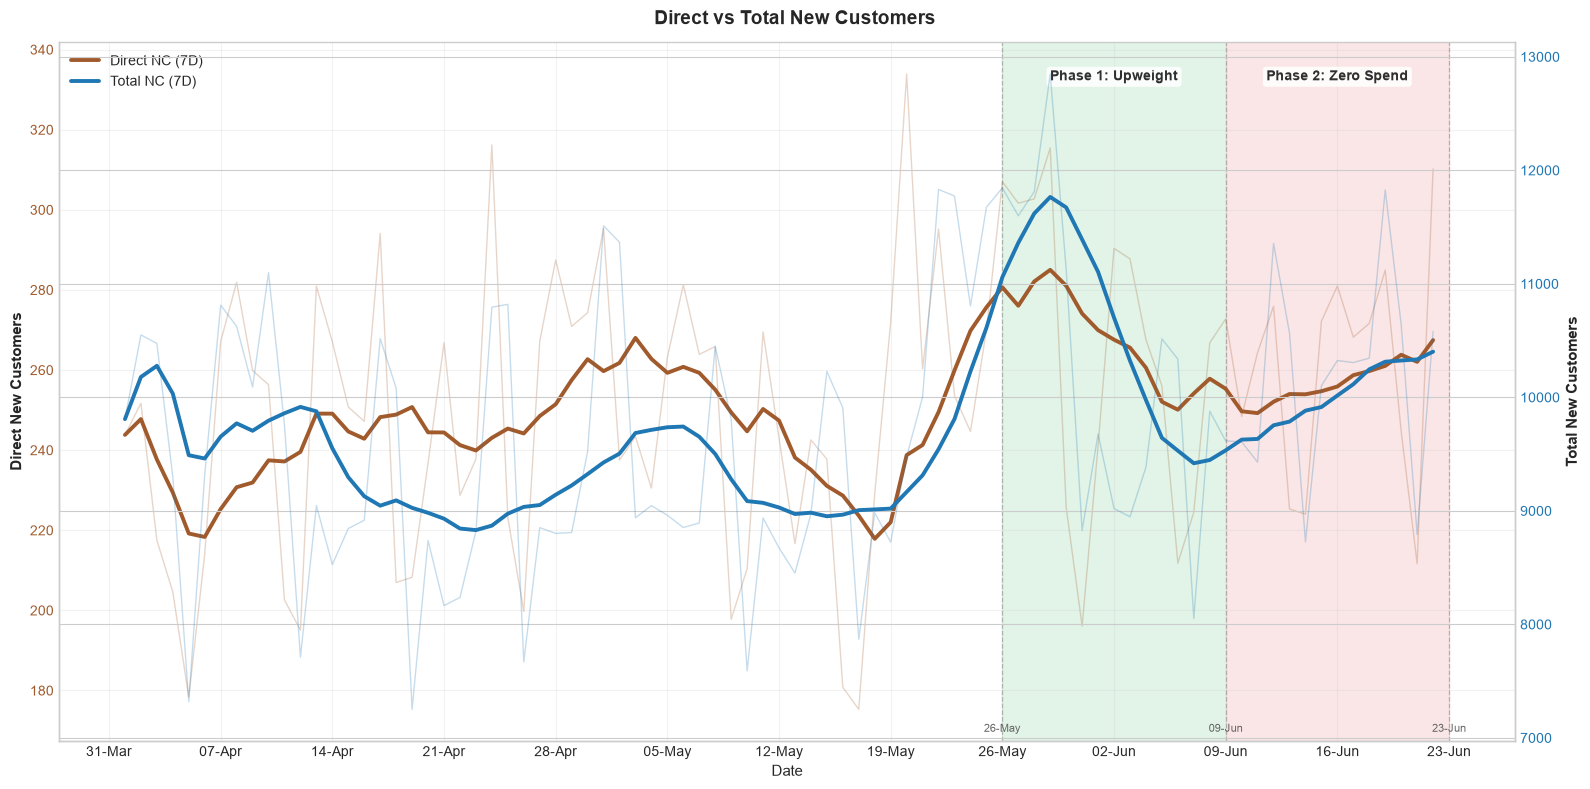


✅ Direct vs Total NC dual-axis chart created!


In [138]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-whitegrid")

# Prepare data for Direct vs Total NC chart (dual axis)
df_nc_dt = df.sort_values("activity_date").copy()
df_nc_dt = df_nc_dt[df_nc_dt["activity_date"] >= pd.Timestamp("2026-04-01")].copy()

# Calculate 7D rolling averages
df_nc_dt["total_nc_7d"] = df_nc_dt["total_new_customers"].rolling(7, min_periods=1).mean()
df_nc_dt["direct_nc_7d"] = df_nc_dt["web_direct_new_customers"].rolling(7, min_periods=1).mean()

# Create figure with dual axes
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Define phase windows
phase_windows = [
    {"label": "Phase 1: Upweight", "start": upweight_date, "end": zero_date, "color": "#cdeed8"},
    {"label": "Phase 2: Zero Spend", "start": zero_date, "end": restore_date, "color": "#f7d6d6"},
]

# Add phase shading (behind all plots)
for w in phase_windows:
    ax1.axvspan(w["start"], w["end"], color=w["color"], alpha=0.6, zorder=0)

# --- Primary Axis (Left): Direct NC ---
ax1.plot(df_nc_dt["activity_date"], df_nc_dt["web_direct_new_customers"], alpha=0.25, lw=1.0, color="#a05a2c")
line1 = ax1.plot(df_nc_dt["activity_date"], df_nc_dt["direct_nc_7d"], lw=2.8, color="#a05a2c", label="Direct NC (7D)", zorder=5)
ax1.set_ylabel("Direct New Customers", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#a05a2c")

# --- Secondary Axis (Right): Total NC ---
ax2.plot(df_nc_dt["activity_date"], df_nc_dt["total_new_customers"], alpha=0.25, lw=1.0, color="#1f77b4")
line2 = ax2.plot(df_nc_dt["activity_date"], df_nc_dt["total_nc_7d"], lw=2.8, color="#1f77b4", label="Total NC (7D)", zorder=5)
ax2.set_ylabel("Total New Customers", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

ax1.set_xlabel("Date", fontsize=11)
ax1.grid(True, alpha=0.25)
ax1.spines["top"].set_visible(False)

# Add phase labels
ymin, ymax = ax1.get_ylim()
y = ymax - 0.04 * (ymax - ymin)
for w in phase_windows:
    x = w["start"] + (w["end"] - w["start"]) / 2
    ax1.text(
        x,
        y,
        w["label"],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#2f2f2f",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        zorder=10,
    )

# Add vertical boundary lines
boundary_dates = [
    (upweight_date, "26-May"),
    (zero_date, "09-Jun"),
    (restore_date, "23-Jun"),
]
for date, label in boundary_dates:
    ax1.axvline(date, linestyle="--", linewidth=0.9, color="#666666", alpha=0.4, zorder=1)
    ymin_val, ymax_val = ax1.get_ylim()
    ax1.text(
        date,
        ymin_val + 0.01 * (ymax_val - ymin_val),
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#666666",
    )

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10, framealpha=0.95)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)

fig.suptitle("Direct vs Total New Customers", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Direct vs Total NC dual-axis chart created!")

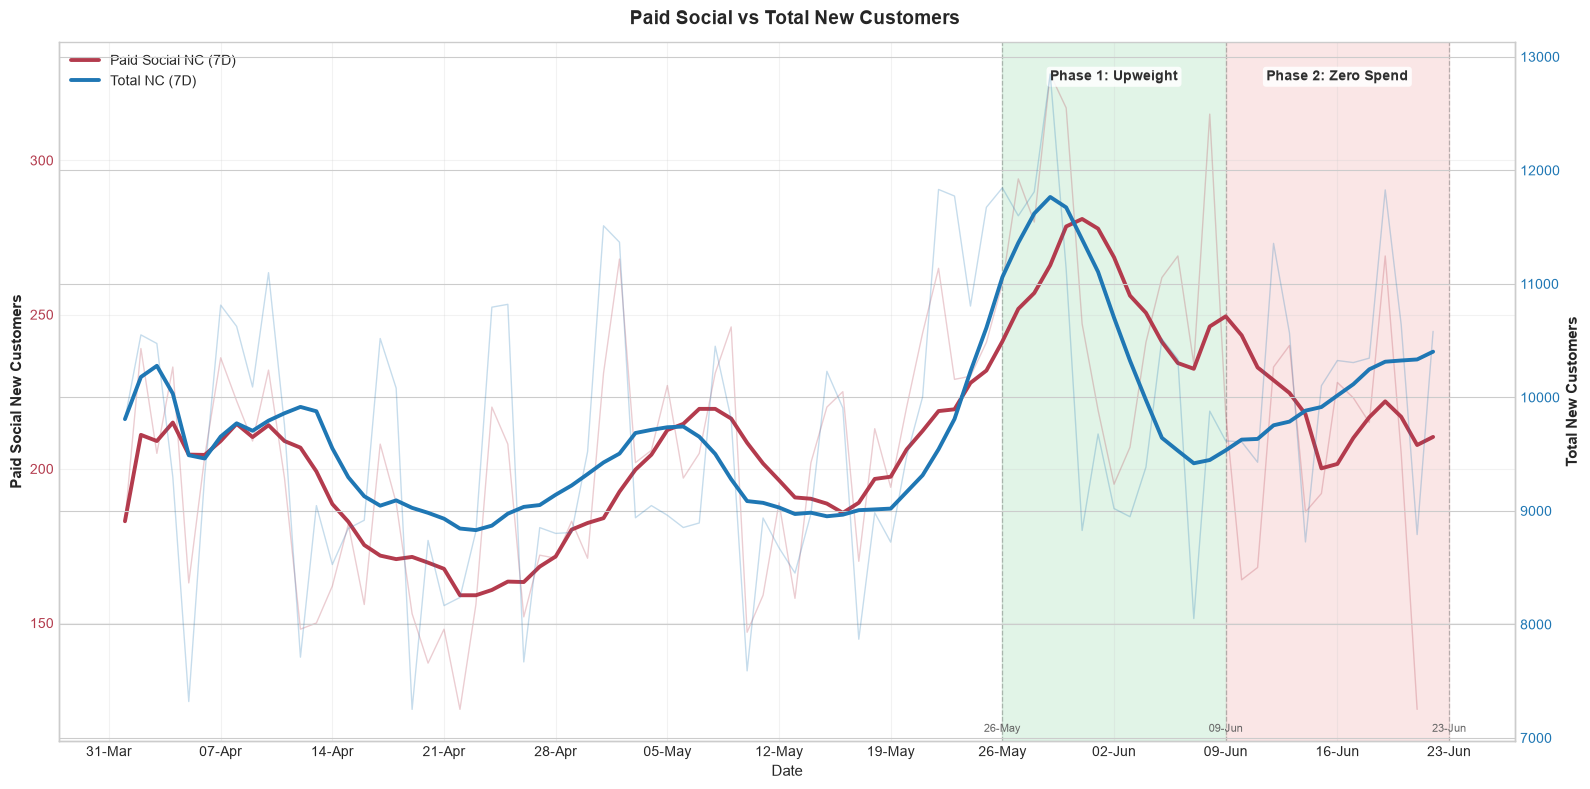


✅ Paid Social vs Total NC dual-axis chart created!


In [139]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-whitegrid")

# Prepare data for Paid Social vs Total NC chart (dual axis)
df_nc_st = df.sort_values("activity_date").copy()
df_nc_st = df_nc_st[df_nc_st["activity_date"] >= pd.Timestamp("2026-04-01")].copy()

# Calculate 7D rolling averages
df_nc_st["total_nc_7d"] = df_nc_st["total_new_customers"].rolling(7, min_periods=1).mean()
df_nc_st["social_nc_7d"] = df_nc_st["web_paid_social_new_customers"].rolling(7, min_periods=1).mean()

# Create figure with dual axes
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Define phase windows
phase_windows = [
    {"label": "Phase 1: Upweight", "start": upweight_date, "end": zero_date, "color": "#cdeed8"},
    {"label": "Phase 2: Zero Spend", "start": zero_date, "end": restore_date, "color": "#f7d6d6"},
]

# Add phase shading (behind all plots)
for w in phase_windows:
    ax1.axvspan(w["start"], w["end"], color=w["color"], alpha=0.6, zorder=0)

# --- Primary Axis (Left): Paid Social NC ---
ax1.plot(df_nc_st["activity_date"], df_nc_st["web_paid_social_new_customers"], alpha=0.25, lw=1.0, color="#b33b4d")
line1 = ax1.plot(df_nc_st["activity_date"], df_nc_st["social_nc_7d"], lw=2.8, color="#b33b4d", label="Paid Social NC (7D)", zorder=5)
ax1.set_ylabel("Paid Social New Customers", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#b33b4d")

# --- Secondary Axis (Right): Total NC ---
ax2.plot(df_nc_st["activity_date"], df_nc_st["total_new_customers"], alpha=0.25, lw=1.0, color="#1f77b4")
line2 = ax2.plot(df_nc_st["activity_date"], df_nc_st["total_nc_7d"], lw=2.8, color="#1f77b4", label="Total NC (7D)", zorder=5)
ax2.set_ylabel("Total New Customers", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

ax1.set_xlabel("Date", fontsize=11)
ax1.grid(True, alpha=0.25)
ax1.spines["top"].set_visible(False)

# Add phase labels
ymin, ymax = ax1.get_ylim()
y = ymax - 0.04 * (ymax - ymin)
for w in phase_windows:
    x = w["start"] + (w["end"] - w["start"]) / 2
    ax1.text(
        x,
        y,
        w["label"],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#2f2f2f",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
        zorder=10,
    )

# Add vertical boundary lines
boundary_dates = [
    (upweight_date, "26-May"),
    (zero_date, "09-Jun"),
    (restore_date, "23-Jun"),
]
for date, label in boundary_dates:
    ax1.axvline(date, linestyle="--", linewidth=0.9, color="#666666", alpha=0.4, zorder=1)
    ymin_val, ymax_val = ax1.get_ylim()
    ax1.text(
        date,
        ymin_val + 0.01 * (ymax_val - ymin_val),
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        color="#666666",
    )

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10, framealpha=0.95)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)

fig.suptitle("Paid Social vs Total New Customers", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Paid Social vs Total NC dual-axis chart created!")

## Clean ROAS analysis

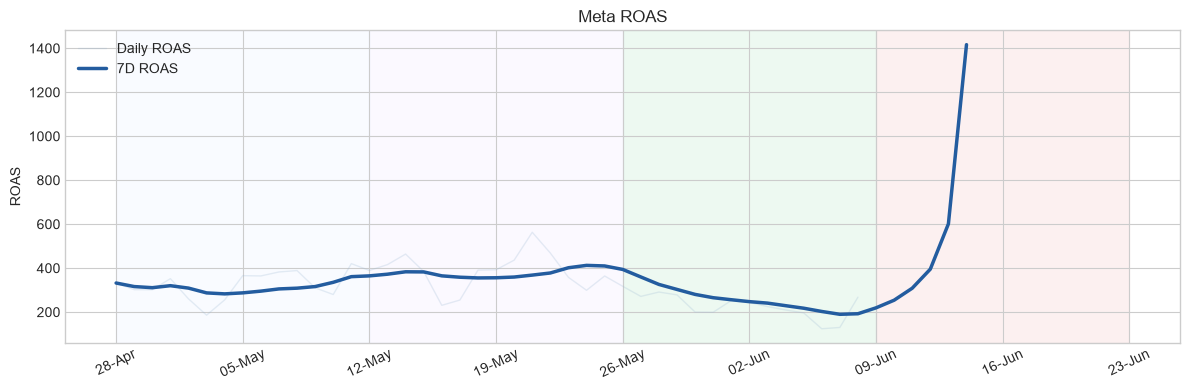

,spend,nts,total_nts,roas,business_iroas
period,,,,,
Pre 1,"29,644.70","9,413,643.26","165,124,898.66",317.55,"5,570.13"
Pre 2,"25,975.61","9,883,834.86","163,195,320.87",380.50,"6,282.64"
Upweight,"51,142.08","11,228,012.10","169,605,709.06",219.55,"3,316.36"
Zero spend,0.00,"9,523,789.20","167,592,075.68",NaN,NaN


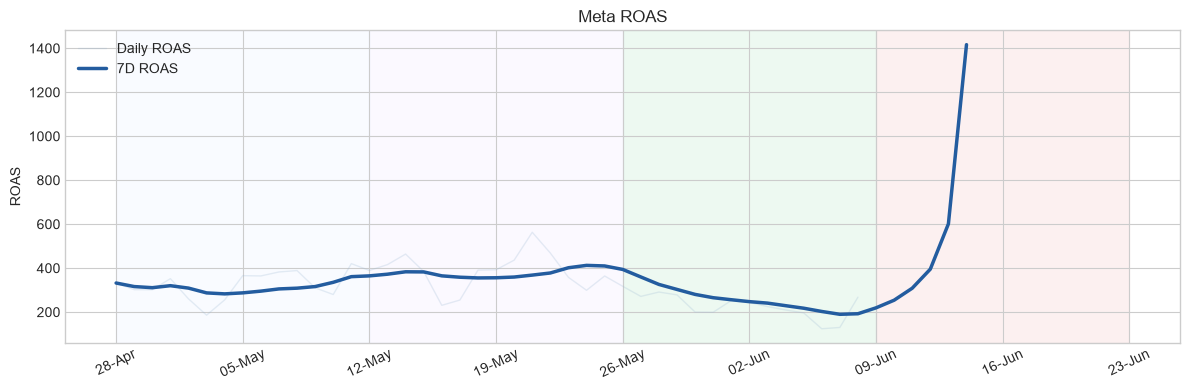

,spend,nts,total_nts,roas,business_iroas
period,,,,,
Pre 1,"29,644.70","9,413,643.26","165,124,898.66",317.55,"5,570.13"
Pre 2,"25,975.61","9,883,834.86","163,195,320.87",380.50,"6,282.64"
Upweight,"51,142.08","11,228,012.10","169,605,709.06",219.55,"3,316.36"
Zero spend,0.00,"9,523,789.20","167,592,075.68",NaN,NaN


iROAS (Paid Social NTS per £1 extra Meta spend): 19.00
Business iROAS (Total NTS per £1 extra Meta spend): 39.37


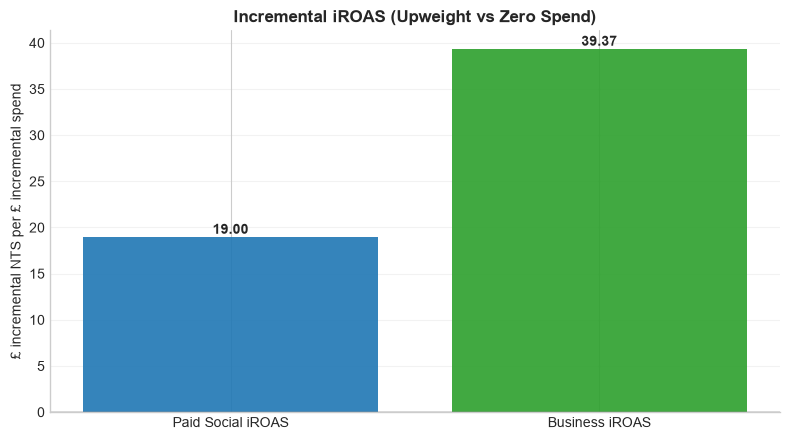

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

roas_df = df_analysis.copy()
roas_df["activity_date"] = pd.to_datetime(roas_df["activity_date"])
roas_df = roas_df.sort_values("activity_date").copy()

pre_1_start = pd.Timestamp("2026-04-28")
pre_1_end = pd.Timestamp("2026-05-11")
pre_2_start = pd.Timestamp("2026-05-12")
pre_2_end = pd.Timestamp("2026-05-25")
upweight_start = pd.Timestamp("2026-05-26")
upweight_end = pd.Timestamp("2026-06-08")
zero_start = pd.Timestamp("2026-06-09")
zero_end = pd.Timestamp("2026-06-22")
restore_start = pd.Timestamp("2026-06-23")

def label_period(date_value):
    if pre_1_start <= date_value <= pre_1_end:
        return "Pre 1"
    if pre_2_start <= date_value <= pre_2_end:
        return "Pre 2"
    if upweight_start <= date_value <= upweight_end:
        return "Upweight"
    if zero_start <= date_value <= zero_end:
        return "Zero spend"
    if date_value >= restore_start:
        return "Restored"
    return np.nan

roas_df["period"] = roas_df["activity_date"].apply(label_period)
roas_df = roas_df[roas_df["period"].notna()].copy()

roas_df["daily_roas"] = roas_df["web_paid_social_scaled_nts_gbp"] / roas_df["facebook_paid_social_spend_gbp"].replace(0, np.nan)
roas_df["roas_7d"] = (
    roas_df["web_paid_social_scaled_nts_gbp"].rolling(7, min_periods=1).sum()
    / roas_df["facebook_paid_social_spend_gbp"].rolling(7, min_periods=1).sum().replace(0, np.nan)
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roas_df["activity_date"], roas_df["daily_roas"], alpha=0.25, lw=1, color="#9bb8d3", label="Daily ROAS")
ax.plot(roas_df["activity_date"], roas_df["roas_7d"], lw=2.5, color="#235c9f", label="7D ROAS")
for start, end, color in [
    (pre_1_start, pre_1_end + pd.Timedelta(days=1), "#eef5ff"),
    (pre_2_start, pre_2_end + pd.Timedelta(days=1), "#f4f0ff"),
    (upweight_start, upweight_end + pd.Timedelta(days=1), "#cdeed8"),
    (zero_start, zero_end + pd.Timedelta(days=1), "#f7d6d6"),
]:
    ax.axvspan(start, end, color=color, alpha=0.35, zorder=0)
ax.set_title("Meta ROAS")
ax.set_ylabel("ROAS")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.xticks(rotation=25)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

period_roas = (
    roas_df.groupby("period", observed=True)
    .agg(
        spend=("facebook_paid_social_spend_gbp", "sum"),
        nts=("web_paid_social_scaled_nts_gbp", "sum"),
        total_nts=("total_nts_gbp", "sum"),
    )
)
period_roas["roas"] = period_roas["nts"] / period_roas["spend"].replace(0, np.nan)
period_roas["business_iroas"] = period_roas["total_nts"] / period_roas["spend"].replace(0, np.nan)

display(period_roas.round(2))

period_avg = roas_df.groupby("period", observed=True).agg(
    facebook_paid_social_spend_gbp=("facebook_paid_social_spend_gbp", "mean"),
    web_paid_social_scaled_nts_gbp=("web_paid_social_scaled_nts_gbp", "mean"),
    total_nts_gbp=("total_nts_gbp", "mean"),
)

iroas = (
    period_avg.loc["Upweight", "web_paid_social_scaled_nts_gbp"] - period_avg.loc["Zero spend", "web_paid_social_scaled_nts_gbp"]
) / (
    period_avg.loc["Upweight", "facebook_paid_social_spend_gbp"] - period_avg.loc["Zero spend", "facebook_paid_social_spend_gbp"]
)

business_iroas = (
    period_avg.loc["Upweight", "total_nts_gbp"] - period_avg.loc["Zero spend", "total_nts_gbp"]
) / (
    period_avg.loc["Upweight", "facebook_paid_social_spend_gbp"] - period_avg.loc["Zero spend", "facebook_paid_social_spend_gbp"]
)

print(f"iROAS (Paid Social NTS per £1 extra Meta spend): {iroas:.2f}")
print(f"Business iROAS (Total NTS per £1 extra Meta spend): {business_iroas:.2f}")